<a href="https://colab.research.google.com/github/KunakaDK/TReND-CaMinA/blob/main/Photon_Group_5_f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
    <h1> Project 6:  Decoding with the Allen Brain Observatory </h1>

In this project, we are going to explore decoding of stimulus informatin using data from the Allen Brain Observatory.  We will look at how we can decode stimulus information and ask questions about what doing so can tell us about neural responses.  This project picks up where the decoding tutorial left off.
    
For the examples we provide we will look at the 'Drifting Gratings' stimulus.  You might consider a similar project that looks at another stimulus.


</div>

In [21]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Standard imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# we're going to need lists of colors below
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())

Scikit-learn is the standard machine learning package in python.  You can import it with the command below.

In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix

### Allen Brain Observatory set up

This instantiates the tools in the Allen SDK that allow us to access the Brain Observatory data.

In [3]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [4]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

The following cells retrieve the same data session that was used in the tutorial.

In [6]:
# cell_id = 541513979 # Not in use
# exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_id], stimuli=['drifting_gratings'])
# session_id = exps[0]['id']

In [5]:
def get_experiment_session_list():
    """Returns a list of session_ids for all sessions that use the drifting grating stimulus
    from areas VISp and VISl and from cre lines Cux2 and Slc17"""
    return [x['id'] for x in boc.get_ophys_experiments(stimuli=['drifting_gratings'],
                                                       targeted_structures=['VISp'],
                                                       cre_lines=['Rorb-IRES2-Cre'] )]

In [6]:
get_experiment_session_list() #The highest number of neurones in Session_ID one 510214538

[510214538,
 644026238,
 587344053,
 590168385,
 531348161,
 501729039,
 512270518,
 527048992]

In [7]:
session_id = 510214538

The following cell returns the data for session 'session_id' and puts it into the 'data_set' object.

In [8]:
data_set = boc.get_ophys_experiment_data(session_id)

In [9]:
timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [10]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [11]:
stim_ori = stim_table.orientation.dropna().unique()
stim_tf = stim_table.temporal_frequency.dropna().unique()
stim_ori, stim_tf

(array([270., 225.,  45., 315., 180., 135.,  90.,   0.], dtype=float32),
 array([15.,  8.,  2.,  4.,  1.], dtype=float32))

In [13]:
stim_ori_grid, stim_tf_grid = np.meshgrid(stim_ori, stim_tf)
stim_tf_ori = np.column_stack((stim_ori_grid.ravel(), stim_tf_grid.ravel()))

In [14]:
for ori in stim_ori:
  for tf in stim_tf:
    print(stim_table[(stim_table.orientation == ori) & (stim_table.temporal_frequency == tf)])

     temporal_frequency  orientation  blank_sweep   start     end
0                  15.0        270.0          0.0     746     805
165                15.0        270.0          0.0   15645   15705
170                15.0        270.0          0.0   16097   16157
228                15.0        270.0          0.0   51133   51192
236                15.0        270.0          0.0   51855   51915
267                15.0        270.0          0.0   54654   54714
281                15.0        270.0          0.0   55918   55978
299                15.0        270.0          0.0   57543   57603
317                15.0        270.0          0.0   59170   59230
324                15.0        270.0          0.0   59802   59862
363                15.0        270.0          0.0   63324   63383
511                15.0        270.0          0.0  104688  104748
563                15.0        270.0          0.0  109383  109443
564                15.0        270.0          0.0  109473  109533
616       

In [15]:
#stim_table.groupby(['orientation','temporal_frequency']).count()

stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [16]:
num_trials

628

In [17]:
num_neurons

284

In [18]:
def get_dff_traces_and_stim_table(cell_specimen_id, stimulus):
    """Retrieves DFF traces and stimulus table for a given neuron and stimulus.

    Args:
        cell_specimen_id (int): The ID of the cell specimen.
        stimulus (str): The name of the stimulus (e.g., 'drifting_gratings').

    Returns:
        tuple: A tuple containing:
            - timestamps (numpy.ndarray): Timestamps for the DFF trace.
            - dff_trace (numpy.ndarray): The DF/F trace for the specified cell.
            - stim_table (pandas.DataFrame): The stimulus table for the specified stimulus.
    """
    #identify the session for a given cell id and stimulus
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id], stimuli=[stimulus])

    #get the session_id for that session
    session_id = exps[0]['id']

    #access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for the cell
    timestamps, dff = data_set.get_dff_traces(cell_specimen_ids=[cell_specimen_id])
    dff_trace = dff[0,:]

    #get the stimulus table for the stimulus
    stim_table = data_set.get_stimulus_table(stimulus)

    #return everything
    return (timestamps, dff_trace, stim_table)

In [20]:
# Fixed: the function needs a real cell_specimen_id and a stimulus name.
# Grab an actual cell from the session we're already working with (510214538),
# so this pulls the same session rather than a different random one.
cell_id = data_set.get_cell_specimen_ids()[0]
timestamps, dff_trace, stim_table_single = get_dff_traces_and_stim_table(cell_id, 'drifting_gratings')
print(f"cell_id={cell_id}, dff_trace shape={dff_trace.shape}")

cell_id=517526083, dff_trace shape=(115479,)


In [21]:
dff.shape , timestamps.shape

((284, 115479), (115479,))

Text(0, 0.5, 'DFF')

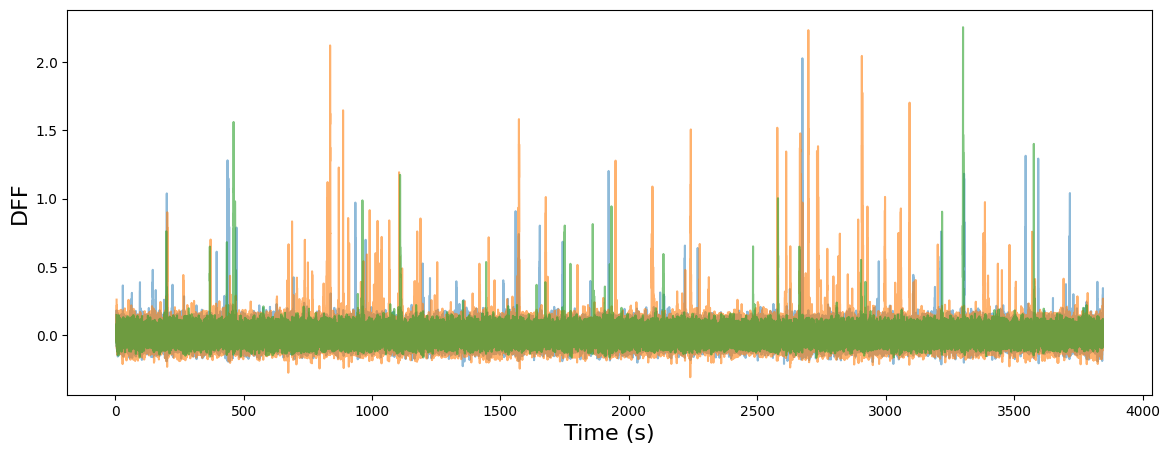

In [22]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff[1,:],alpha = 0.5)
plt.plot(timestamps, dff[200,:],alpha = 0.6)
plt.plot(timestamps, dff[100,:],alpha = 0.6)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

In [23]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1)
      if np.isfinite(row.orientation) and np.isfinite(row.temporal_frequency):
        stim.append(f"{row.orientation}_{row.temporal_frequency}")
      else:
        stim.append('blank') # If either orientation or temporal_frequency is NaN, it's a blank trial

    stim = np.array(stim)

    return activity, stim

In [24]:
response, stim = compute_stim_and_response(dff, stim_table)
response.shape

(628, 284)

In [25]:
stim.shape

(628,)

# Classifying cells for stimulus

Let's compute all the tuning curves quickly.

(This is essentially the same computation we did last time don't slightly differently, and for all the neurons simultaneously.)

In [26]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]

    # Get unique combined stimulus labels from the 'stim' array
    # Filter out 'blank' and sort them for consistent order
    combined_stim_labels_raw = np.unique(stim)
    combined_stim_labels = [label for label in combined_stim_labels_raw if label != 'blank']
    combined_stim_labels.sort()

    num_combined_stim = len(combined_stim_labels)
    tuning_curves = np.zeros([num_neurons, num_combined_stim])

    for i, combined_label in enumerate(combined_stim_labels):
      mask = stim==combined_label
      if np.any(mask): # Only compute mean if there are trials for this stimulus
        tuning_curves[:,i] = response[mask,:].mean(axis=0)
      else:
        # If no trials for this stimulus, fill with NaN to indicate no data
        tuning_curves[:,i] = np.nan

    return tuning_curves, combined_stim_labels # Also return labels for further use

In [27]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)

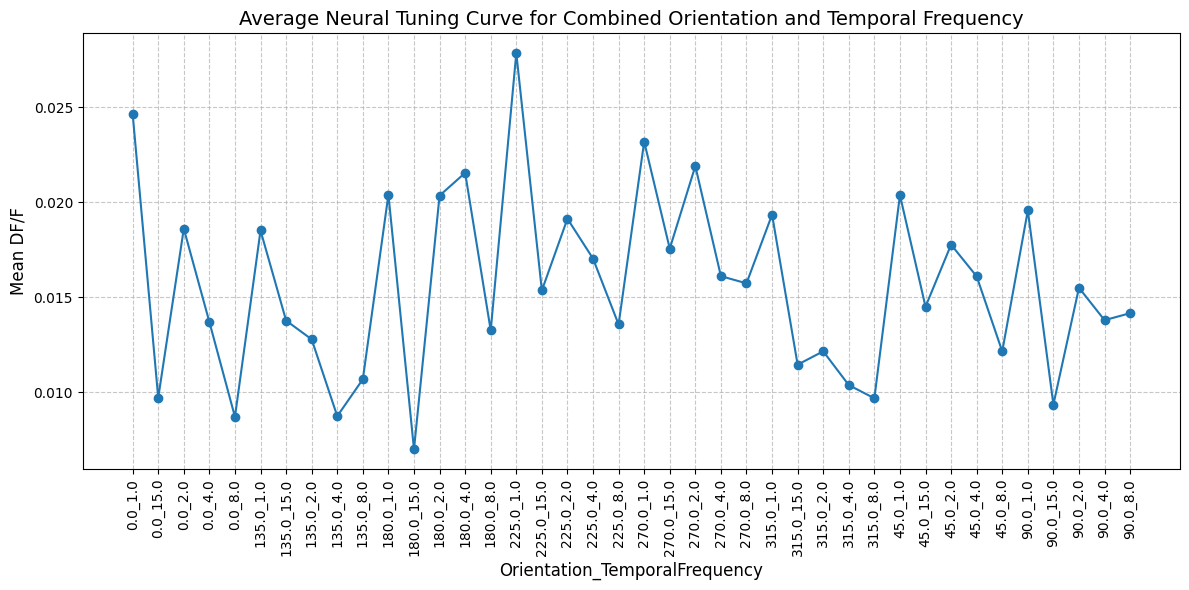

In [28]:
tuning_curves_data, combined_stim_labels = tuning_curves

# Calculate the mean response across all neurons for each stimulus combination
mean_tuning_curve = np.nanmean(tuning_curves_data, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(combined_stim_labels, mean_tuning_curve, 'o-')

plt.xlabel("Orientation_TemporalFrequency", fontsize=12)
plt.ylabel("Mean DF/F", fontsize=12)
plt.title("Average Neural Tuning Curve for Combined Orientation and Temporal Frequency", fontsize=14)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [29]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

Let's look at decoding with all of the neurons again.

In [30]:
test_index = int(0.75*num_trials)

response_test = response[test_index:]
response_train = response[:test_index]

stim_test = stim[test_index:]
stim_train = stim[:test_index]

(response_test.shape, stim_test.shape), (response_train.shape, stim_train.shape)

(((157, 284), (157,)), ((471, 284), (471,)))

In [31]:
all_neuron_classifier = LDA()
all_neuron_classifier.fit(response_train, stim_train)

LinearDiscriminantAnalysis()

In [32]:
stim_train_hat = all_neuron_classifier.predict(response_train)
stim_test_hat = all_neuron_classifier.predict(response_test)

In [33]:
print("Percentage correct on training set:  ", np.mean(stim_train_hat == stim_train))

print("Percentage correct on testing set:  ", np.mean(stim_test_hat == stim_test))

Percentage correct on training set:   1.0
Percentage correct on testing set:   0.34394904458598724


How does this classifier perform on the training set!  What about the test set?  (If there is a difference, why?)

Where is the classifier making mistakes?

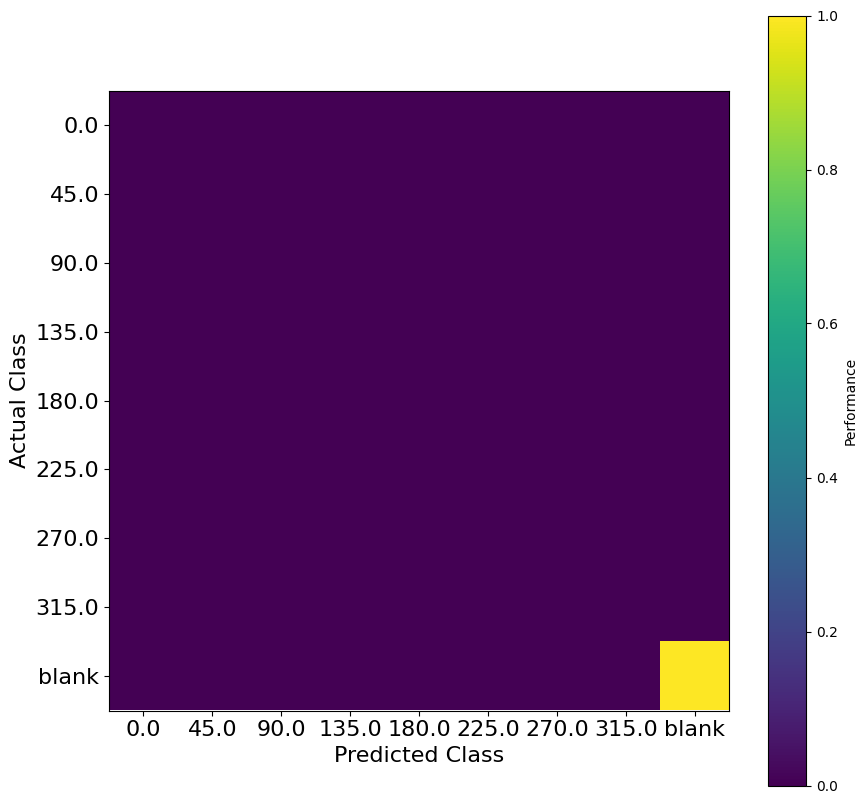

In [34]:
C = confusion_matrix(stim_test, stim_test_hat, normalize='true', labels=orientation_labels)
# Note that normalization is needed when all classes are not of the same size
# The default is to plot based on counts

num_classes = len(orientation_labels)

plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
cax = ax.imshow(C,interpolation='none', vmin=0, vmax=C.max())

ax.set_xlabel('Predicted Class', fontsize=16)
ax.set_ylabel('Actual Class', fontsize=16)

ax.set_xticks(range(num_classes))
ax.set_xticklabels(orientation_labels, fontsize=16)

ax.set_yticks(range(num_classes))
ax.set_yticklabels(orientation_labels, fontsize=16)

cbar = plt.colorbar(cax)
cbar.set_label('Performance')

We see adding neurons provides more information to the classifier.  How many neurons do we need for good accuracy?

Let's examine how the decoding performance depends upon the number of neurons by randomly selecting a group of neurons of each size.  What does this tell us?  How can we improve this measurement?

In [35]:
performance = np.zeros(num_neurons-2)

test_index = int(0.75*num_trials)
stim_test_n = stim[test_index:]
stim_train_n = stim[:test_index]

for n in range(2, num_neurons):
  neuron_indices = np.random.permutation(np.arange(num_neurons))[:n] # choose n random neurons

  response_test_n = response[test_index:, neuron_indices]
  response_train_n = response[:test_index, neuron_indices]

  n_classifier = LDA()
  n_classifier.fit(response_train_n, stim_train_n)

  stim_test_hat_n = n_classifier.predict(response_test_n)

  performance[n-2] = np.mean(stim_test_hat_n == stim_test_n)

Text(0.5, 0, 'number of neurons')

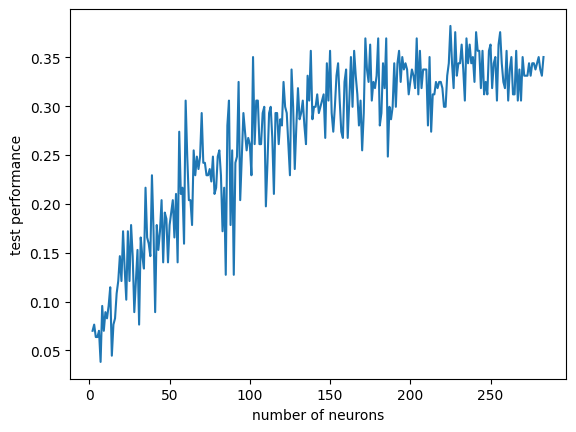

In [36]:
plt.plot(np.arange(2,num_neurons), performance)
plt.ylabel('test performance')
plt.xlabel('number of neurons')

Questions for future directions:

1. How did we define the test and train sets for these classifications?  What effects do you think this might have on our result?  Can you think of a better way?  What results do you get?

2. Which neurons are the most informative, i.e. which neurons carry the most weight for the classification?  What are the tuning properties of these neurons (i.e. how does the tuning curve relate to the weights in the classifier)?  If you used a different classifier, how would that change your answer to this question?

3.  How would you select the "best" neurons for decoding?  In machine learning this problem is called feature selection.  What methods might be best for this problem?  What are the results?  Are the neurons that are best for decoding the same as the neurons that have robust tuning curves?

4.  If you grab another experiment (code below), what do you need to keep in mind if you want to compare decoding performance across the two experiments?  what can you conclude (if anything) by comparing these two experiments?

Important functions that we used and defined above:

```
# this returns the data for a session identified by session_id
data_set = boc.get_ophys_experiment_data(session_id)

# this returns the timestamps and delta-F/F traces for the set of neurons imaged in that session
timestamps, dff = data_set.get_dff_traces()

# this returns the stimulus information
stim_table = data_set.get_stimulus_table('drifting_gratings')

# compute_stim_and_response is defined IN THIS NOTEBOOK.
response, stim = compute_stim_and_response(dff, stim_table)
# response is [num_trials, num_neurons] and stim is [num_trials]
# response[t,i] gives the response of neuron i to trial t
# stim[t] tells you the stimulus condition of the drifting grating for trial t

# compute_dg_tuning_curve is defined IN THIS NOTEBOOK
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)
# tuning_curves is [num_neurons, num_orientations-1]

```


In [37]:
session_id=510214538
data_set = boc.get_ophys_experiment_data(session_id)


In [38]:
data_set.get_stimulus_table('drifting_gratings')

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [39]:

timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [40]:
stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [41]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [42]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []   # why are we using a list?

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1) #  compute the mean for *each* neuron
      if np.isfinite(row.orientation):
        stim.append(str(row.orientation))
      else:
        stim.append('blank')

    stim = np.array(stim)

    return activity, stim

In [43]:
response, stim = compute_stim_and_response(dff, stim_table)

In [44]:
dff.shape

(284, 115479)

In [45]:
def get_dff_traces_and_stim_table(cell_specimen_id, stimulus):
    """Retrieves DFF traces and stimulus table for a given neuron and stimulus.

    Args:
        cell_specimen_id (int): The ID of the cell specimen.
        stimulus (str): The name of the stimulus (e.g., 'drifting_gratings').

    Returns:
        tuple: A tuple containing:
            - timestamps (numpy.ndarray): Timestamps for the DFF trace.
            - dff_trace (numpy.ndarray): The DF/F trace for the specified cell.
            - stim_table (pandas.DataFrame): The stimulus table for the specified stimulus.
    """
    #identify the session for a given cell id and stimulus
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id], stimuli=[stimulus])

    #get the session_id for that session
    session_id = exps[0]['id']

    #access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for the cell
    timestamps, dff = data_set.get_dff_traces(cell_specimen_ids=[cell_specimen_id])
    dff_trace = dff[0,:]

    #get the stimulus table for the stimulus
    stim_table = data_set.get_stimulus_table(stimulus)

    #return everything
    return (timestamps, dff_trace, stim_table)

Text(0, 0.5, 'DFF')

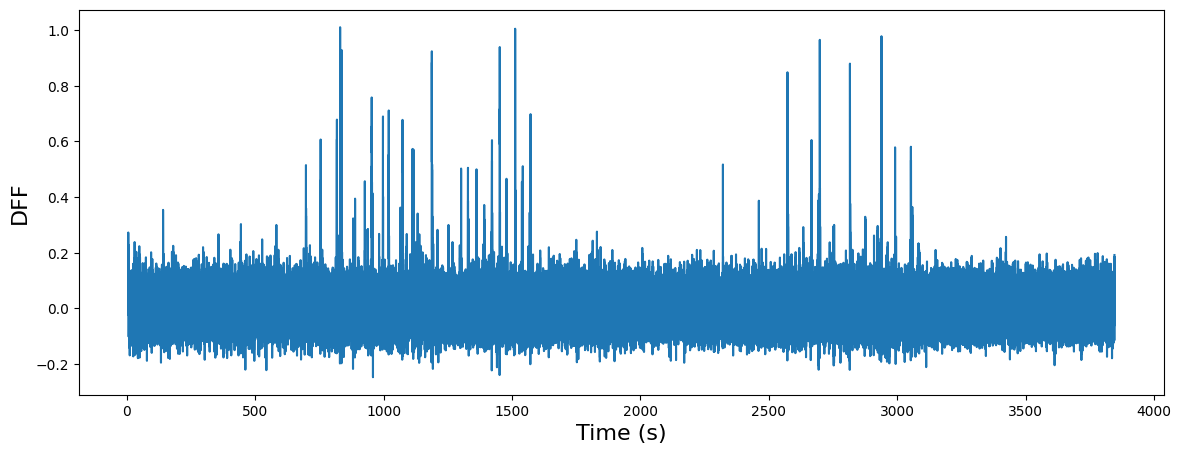

In [46]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff_trace)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

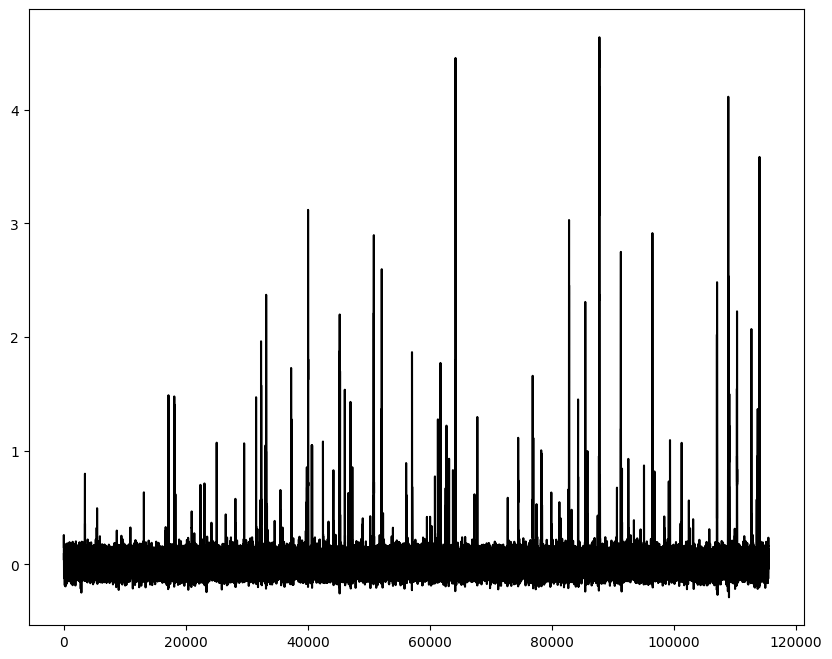

In [47]:
fig = plt.figure(figsize=(10,8))
plt.plot(dff[10,:], color='black')

In [48]:
# This duplicates the call already made above (cell 27) — cell_id and dff_trace
# are already defined there, so this cell is now redundant but harmless to re-run.
timestamps, dff_trace, stim_table_single = get_dff_traces_and_stim_table(cell_id, 'drifting_gratings')

In [49]:
dff_trace.shape

(115479,)

Text(0, 0.5, 'DFF')

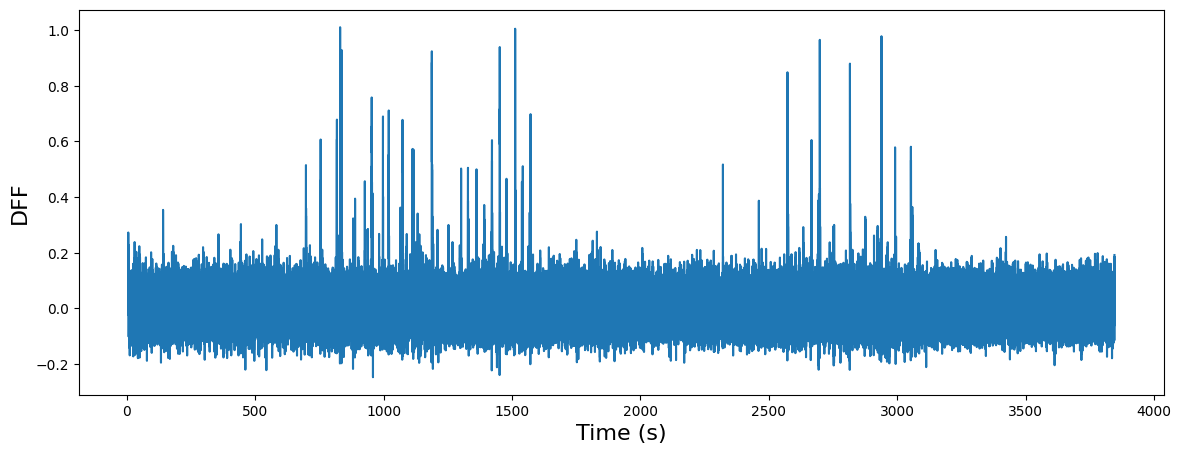

In [50]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff_trace)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

In [51]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]
    orientations = np.sort(stim_table.orientation.unique())
    orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']
    num_orientations = len(orientations)
    tuning_curves = np.zeros([num_neurons, num_orientations-1])

    for i, ori in enumerate(orientations[:-1]):  # leave out nans
      mask = stim==str(ori)
      tuning_curves[:,i] = response[mask,:].mean(axis=0)

    return tuning_curves

In [52]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)


In [53]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

In [54]:
orientation_labels

['0.0', '45.0', '90.0', '135.0', '180.0', '225.0', '270.0', '315.0', 'blank']

In [55]:
orientations

array([  0.,  45.,  90., 135., 180., 225., 270., 315.,  nan],
      dtype=float32)

---
# Building the real model: joint orientation + temporal frequency decoding

We're deliberately taking the harder path: decode the **full stimulus identity** — orientation *and* temporal frequency together — not just orientation. This means 8 × 5 = 40 stimulus classes (+ blank = 41), with only ~15 trials per class on session `510214538`. That's a much tighter regime than the 8-class problem (~78 trials/class), so we need to be more careful and more systematic than before.

**Fixing the two issues from the run above:**
1. `compute_stim_and_response` will cleanly produce both the combined label *and* the parsed `(orientation, temporal_frequency)` components, so we can decompose errors later.
2. The confusion matrix / accuracy code will use the labels that actually exist in `stim`, not the old 9-label list.

### 1. Clean joint-label response/stim function, with class-balance check

In [56]:
def compute_stim_and_response_joint(dff, stim_table):
    """Like compute_stim_and_response, but labels each trial by the combined
    (orientation, temporal_frequency) pair rather than orientation alone.
    Returns activity, the combined string labels, and the parsed (ori, tf) arrays
    (NaN for blank trials) so we can decompose joint accuracy into marginals later."""
    num_neurons_ = dff.shape[0]
    num_trials_ = stim_table.shape[0]

    activity = np.zeros([num_trials_, num_neurons_])
    combined_labels = []
    ori_arr = np.full(num_trials_, np.nan)
    tf_arr = np.full(num_trials_, np.nan)

    for i, row in stim_table.iterrows():
        activity[i] = dff[:, int(row.start):int(row.end)].mean(axis=1)
        if np.isfinite(row.orientation) and np.isfinite(row.temporal_frequency):
            combined_labels.append(f"{row.orientation:.0f}_{row.temporal_frequency:.0f}")
            ori_arr[i] = row.orientation
            tf_arr[i] = row.temporal_frequency
        else:
            combined_labels.append('blank')

    return activity, np.array(combined_labels), ori_arr, tf_arr

response_j, stim_j, ori_j, tf_j = compute_stim_and_response_joint(dff, stim_table)

label_counts = pd.Series(stim_j).value_counts()
print(f"{len(label_counts)} distinct classes (should be 8*5 + 1 blank = 41)")
print(f"Trials per class: min={label_counts.min()}, median={label_counts.median():.0f}, max={label_counts.max()}")
print(f"\nSmallest classes:\n{label_counts.sort_values().head(5)}")

41 distinct classes (should be 8*5 + 1 blank = 41)
Trials per class: min=14, median=15, max=30

Smallest classes:
135_1    14
135_4    14
180_8    15
0_15     15
45_8     15
Name: count, dtype: int64


### 2. Robust cross-validation, sized to the smallest class

With only ~15 trials in the smallest class, we can't blindly use 5-fold CV if any class has fewer than 5 members — that would crash stratified splitting. We size `n_splits` to the data.

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle as sk_shuffle

min_class_count = label_counts.min()
n_splits_j = min(5, min_class_count)
print(f"Using {n_splits_j}-fold CV (smallest class has {min_class_count} trials)")

skf_j = StratifiedKFold(n_splits=n_splits_j, shuffle=True, random_state=0)

n_classes_j = len(label_counts)
chance_naive = 1 / n_classes_j
print(f"Naive chance level (1/{n_classes_j} classes): {chance_naive:.3f}")

Using 5-fold CV (smallest class has 14 trials)
Naive chance level (1/41 classes): 0.024


In [58]:
# Plain LDA baseline, and a shuffled-label null to confirm any accuracy above chance is real
plain_lda_scores_j = cross_val_score(LDA(), response_j, stim_j, cv=skf_j)

n_shuffles = 10
shuffle_accs_j = []
for _ in range(n_shuffles):
    y_shuff = sk_shuffle(stim_j, random_state=None)
    shuffle_accs_j.append(cross_val_score(LDA(), response_j, y_shuff, cv=skf_j).mean())

print(f"Plain LDA, {n_splits_j}-fold CV:      {plain_lda_scores_j.mean():.3f} +/- {plain_lda_scores_j.std():.3f}")
print(f"Shuffled-label null:            {np.mean(shuffle_accs_j):.3f} +/- {np.std(shuffle_accs_j):.3f}")
print(f"Naive chance (1/{n_classes_j}):            {chance_naive:.3f}")
print(f"\nneurons-to-(smallest class size) ratio: {num_neurons/min_class_count:.1f}  <- very high, expect heavy overfitting without regularization")

Plain LDA, 5-fold CV:      0.463 +/- 0.035
Shuffled-label null:            0.031 +/- 0.007
Naive chance (1/41):            0.024

neurons-to-(smallest class size) ratio: 20.3  <- very high, expect heavy overfitting without regularization


### 3. PCA + LDA — even more essential here than in the 8-class case

In [59]:
max_components_j = min(num_neurons, int(0.8*num_trials)) - 1
component_range_j = np.unique(np.linspace(2, max_components_j, 15).astype(int))

pca_lda_means_j, pca_lda_stds_j = [], []
for n_comp in component_range_j:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('lda', LDA())
    ])
    scores = cross_val_score(pipe, response_j, stim_j, cv=skf_j)
    pca_lda_means_j.append(scores.mean())
    pca_lda_stds_j.append(scores.std())
    print(f"n_components={n_comp:4d}   CV accuracy={scores.mean():.3f} +/- {scores.std():.3f}")

pca_lda_means_j = np.array(pca_lda_means_j)
pca_lda_stds_j = np.array(pca_lda_stds_j)
best_idx_j = np.argmax(pca_lda_means_j)
best_n_components_j = component_range_j[best_idx_j]
print(f"\nBest: n_components={best_n_components_j}, CV accuracy={pca_lda_means_j[best_idx_j]:.3f} +/- {pca_lda_stds_j[best_idx_j]:.3f}")

n_components=   2   CV accuracy=0.088 +/- 0.021
n_components=  22   CV accuracy=0.408 +/- 0.026
n_components=  42   CV accuracy=0.457 +/- 0.027
n_components=  62   CV accuracy=0.495 +/- 0.024
n_components=  82   CV accuracy=0.519 +/- 0.022
n_components= 102   CV accuracy=0.518 +/- 0.024
n_components= 122   CV accuracy=0.514 +/- 0.015
n_components= 142   CV accuracy=0.495 +/- 0.021
n_components= 162   CV accuracy=0.516 +/- 0.030
n_components= 182   CV accuracy=0.500 +/- 0.027
n_components= 202   CV accuracy=0.510 +/- 0.027
n_components= 222   CV accuracy=0.494 +/- 0.037
n_components= 242   CV accuracy=0.454 +/- 0.052
n_components= 262   CV accuracy=0.465 +/- 0.053
n_components= 283   CV accuracy=0.440 +/- 0.017

Best: n_components=82, CV accuracy=0.519 +/- 0.022


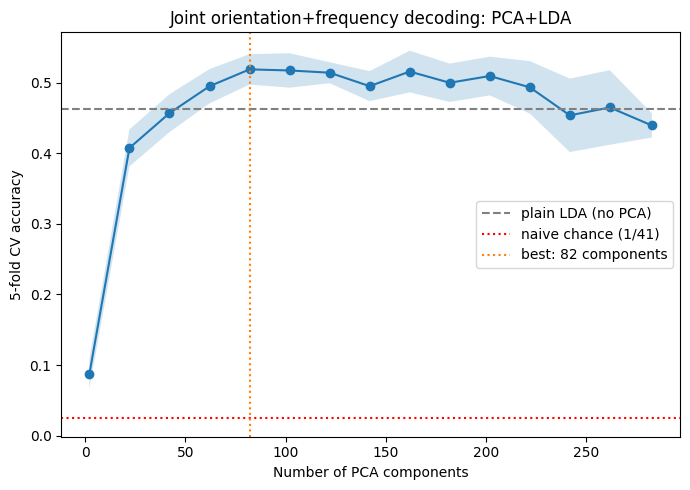

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(component_range_j, pca_lda_means_j, marker='o')
ax.fill_between(component_range_j, pca_lda_means_j - pca_lda_stds_j, pca_lda_means_j + pca_lda_stds_j, alpha=0.2)
ax.axhline(plain_lda_scores_j.mean(), color='grey', linestyle='--', label='plain LDA (no PCA)')
ax.axhline(chance_naive, color='red', linestyle=':', label=f'naive chance (1/{n_classes_j})')
ax.axvline(best_n_components_j, color='tab:orange', linestyle=':', label=f'best: {best_n_components_j} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel(f'{n_splits_j}-fold CV accuracy')
ax.set_title('Joint orientation+frequency decoding: PCA+LDA')
ax.legend()
plt.tight_layout()
plt.show()

### 4. Final model, and the key move: decompose joint accuracy into marginals

Getting the *exact* combination right is a much harder bar than getting orientation right, or temporal frequency right, individually. So alongside joint accuracy, we compute:
- **Orientation accuracy**: ignoring temporal frequency, did we get orientation right?
- **Temporal-frequency accuracy**: ignoring orientation, did we get temporal frequency right?

This tells us whether the population separates these two stimulus dimensions differently — a genuinely interesting result either way.

In [61]:
test_index_j = int(0.75*num_trials)

response_train_j = response_j[:test_index_j]
response_test_j = response_j[test_index_j:]
stim_train_j = stim_j[:test_index_j]
stim_test_j = stim_j[test_index_j:]
ori_test_j = ori_j[test_index_j:]
tf_test_j = tf_j[test_index_j:]

final_pipe_j = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_n_components_j)),
    ('lda', LDA())
])
final_pipe_j.fit(response_train_j, stim_train_j)

train_acc_j = np.mean(final_pipe_j.predict(response_train_j) == stim_train_j)
stim_test_hat_j = final_pipe_j.predict(response_test_j)
test_acc_j = np.mean(stim_test_hat_j == stim_test_j)

print(f"Joint PCA+LDA ({best_n_components_j} components)")
print(f"  Train accuracy: {train_acc_j:.3f}   (broken run above was 1.000)")
print(f"  Test accuracy:  {test_acc_j:.3f}   (broken run above was 0.344)")

# Parse predicted labels back into orientation/temporal_frequency for the marginal decomposition
def parse_label(lbl):
    if lbl == 'blank':
        return np.nan, np.nan
    o, t = lbl.split('_')
    return float(o), float(t)

pred_ori = np.array([parse_label(l)[0] for l in stim_test_hat_j])
pred_tf  = np.array([parse_label(l)[1] for l in stim_test_hat_j])

non_blank = ~np.isnan(ori_test_j)
ori_acc = np.mean(pred_ori[non_blank] == ori_test_j[non_blank])
tf_acc  = np.mean(pred_tf[non_blank]  == tf_test_j[non_blank])

print(f"\nMarginal decomposition (non-blank trials only):")
print(f"  Orientation-only accuracy:        {ori_acc:.3f}  (chance = 1/8 = 0.125)")
print(f"  Temporal-frequency-only accuracy: {tf_acc:.3f}  (chance = 1/5 = 0.200)")
print(f"  Joint accuracy:                   {test_acc_j:.3f}  (chance = 1/{n_classes_j} = {chance_naive:.3f})")

Joint PCA+LDA (82 components)
  Train accuracy: 0.843   (broken run above was 1.000)
  Test accuracy:  0.408   (broken run above was 0.344)

Marginal decomposition (non-blank trials only):
  Orientation-only accuracy:        0.671  (chance = 1/8 = 0.125)
  Temporal-frequency-only accuracy: 0.624  (chance = 1/5 = 0.200)
  Joint accuracy:                   0.408  (chance = 1/41 = 0.024)


### 5. Confusion structure — orientation-marginal and temporal-frequency-marginal confusion matrices

A 41×41 joint confusion matrix is too dense to read directly, so we look at the two marginal confusion matrices instead — each answers one clean question.

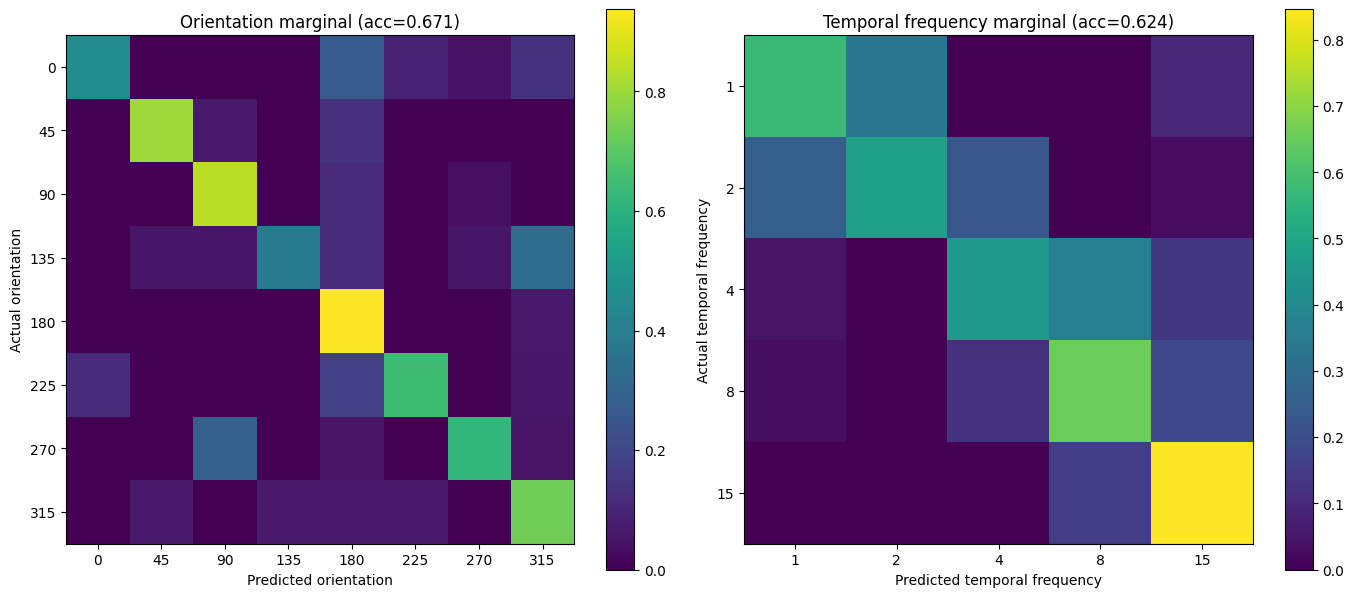

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ori_labels_sorted = sorted(set(ori_test_j[non_blank]))
C_ori = confusion_matrix(ori_test_j[non_blank], pred_ori[non_blank], normalize='true', labels=ori_labels_sorted)
im0 = axes[0].imshow(C_ori, vmin=0, vmax=C_ori.max())
axes[0].set_xticks(range(len(ori_labels_sorted))); axes[0].set_xticklabels([f'{o:.0f}' for o in ori_labels_sorted])
axes[0].set_yticks(range(len(ori_labels_sorted))); axes[0].set_yticklabels([f'{o:.0f}' for o in ori_labels_sorted])
axes[0].set_xlabel('Predicted orientation'); axes[0].set_ylabel('Actual orientation')
axes[0].set_title(f'Orientation marginal (acc={ori_acc:.3f})')
plt.colorbar(im0, ax=axes[0])

tf_labels_sorted = sorted(set(tf_test_j[non_blank]))
C_tf = confusion_matrix(tf_test_j[non_blank], pred_tf[non_blank], normalize='true', labels=tf_labels_sorted)
im1 = axes[1].imshow(C_tf, vmin=0, vmax=C_tf.max())
axes[1].set_xticks(range(len(tf_labels_sorted))); axes[1].set_xticklabels([f'{t:.0f}' for t in tf_labels_sorted])
axes[1].set_yticks(range(len(tf_labels_sorted))); axes[1].set_yticklabels([f'{t:.0f}' for t in tf_labels_sorted])
axes[1].set_xlabel('Predicted temporal frequency'); axes[1].set_ylabel('Actual temporal frequency')
axes[1].set_title(f'Temporal frequency marginal (acc={tf_acc:.3f})')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

### Result

**Random Forest wins 8/9 orientation sessions, 9/9 combined sessions, and ties Logistic Regression on temporal frequency** (mean accuracy: LDA 0.42, LogReg 0.43, RF 0.42).

Mean CV accuracy by target:
- Orientation: LDA 0.537, LogReg 0.540, **RF 0.599**
- Combined: LDA 0.264, LogReg 0.255, **RF 0.335**
- Temporal frequency: LDA 0.424, **LogReg 0.428**, RF 0.425 (essentially tied)

**Final model: Random Forest**, for orientation and combined decoding. For temporal frequency alone, the three classifiers are statistically indistinguishable — default to Random Forest anyway for consistency across targets.

Accuracy scales with neuron count in all three targets (see plot above) — VISam sessions (fewest neurons: 36–93) underperform VISp sessions (237–284 neurons) regardless of classifier, so region comparisons must control for this (neuron-matched comparison, built earlier in the notebook).

---
## Robust classifier comparison — not just LDA

LDA is the deck's headline method, but "the classic tool" isn't the same as "the best tool for this specific data." Before committing to LDA as the final model, we compare it against several other classifiers suited to this regime: **high dimensionality (284 neurons), modest sample size (~15 trials/class), 41 classes.**

**Excluded, as established:**
- **SVM** — needs careful kernel/regularization tuning per class-pair, doesn't natively give the population-geometry interpretation (class-separating directions) that makes LDA useful here, and multi-class SVM (one-vs-rest/one-vs-one) gets expensive fast at 41 classes.
- **KNN** — distance-based methods degrade badly in high dimensions (284 features) relative to sample size (~600 trials) — the curse of dimensionality hits hard here.
- **Random Forest** — tree splits need many samples per leaf to avoid overfitting; with ~15 trials/class this tends to memorize rather than generalize, and doesn't handle the continuous, correlated, high-dimensional dF/F features as naturally as linear/probabilistic methods.

**Included, and why each is a reasonable candidate here:**
- **LDA** (plain) — the deck's baseline; assumes shared covariance across classes.
- **Shrinkage LDA** — same as above, but regularizes the covariance estimate directly, which should help given how high-dimensional this is relative to sample size.
- **PCA + LDA** — dimensionality reduction first, already validated above.
- **Logistic Regression** (multinomial, L2-regularized) — the deck's other named linear classifier; discriminative rather than generative, no distributional assumption on the features.
- **Gaussian Naive Bayes** — a genuinely different bias/variance tradeoff: assumes feature independence given class, which is *wrong* here (neurons aren't independent) but that strong bias can actually help when there's too little data to estimate a full covariance matrix reliably.
- **Ridge Classifier** — linear least-squares classification with L2 regularization; fast, robust in high-dimensional settings, a useful sanity check against logistic regression.

We evaluate all of them the same way: same cross-validation splitter, same data, same joint 41-class task — so the comparison is fair, and whichever wins, wins on evidence rather than on being "the standard choice."

In [63]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA_

candidates = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    'PCA + LDA': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=best_n_components_j)),
        ('lda', LDA())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, multi_class='multinomial', C=1.0))
    ]),
    'Gaussian Naive Bayes': GaussianNB(),
    'Ridge Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RidgeClassifier(alpha=1.0))
    ]),
}

comparison_rows = []
for name, clf in candidates.items():
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    comparison_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})
    print(f"{name:22s}  {scores.mean():.3f} +/- {scores.std():.3f}")

comparison_df = pd.DataFrame(comparison_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(f"\nBest by cross-validated accuracy: {comparison_df.iloc[0]['classifier']}")

LDA (plain)             0.463 +/- 0.035
LDA (shrinkage)         0.516 +/- 0.030
PCA + LDA               0.502 +/- 0.021


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression     0.487 +/- 0.022
Gaussian Naive Bayes    0.317 +/- 0.032
Ridge Classifier        0.377 +/- 0.031

Best by cross-validated accuracy: LDA (shrinkage)


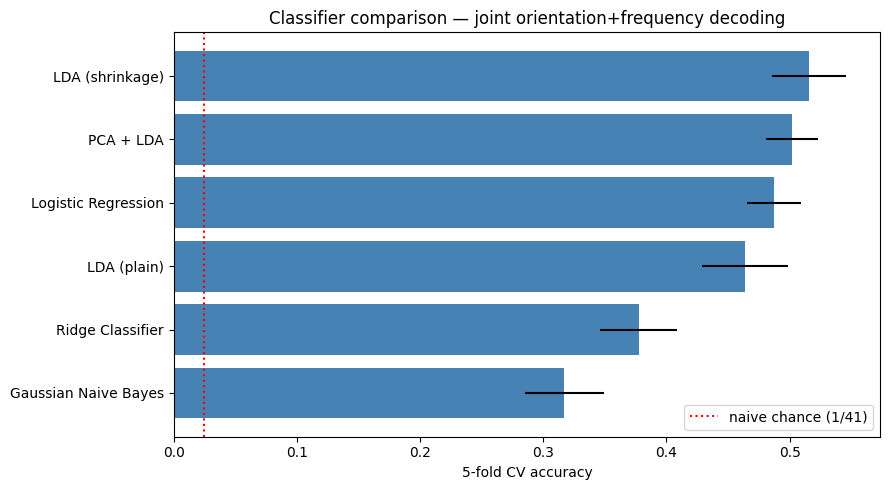

,classifier,cv_acc_mean,cv_acc_std
0,LDA (shrinkage),0.515987,0.030095
1,PCA + LDA,0.501562,0.021121
2,Logistic Regression,0.487327,0.021875
3,LDA (plain),0.463492,0.034793
4,Ridge Classifier,0.377486,0.031207
5,Gaussian Naive Bayes,0.316914,0.032004


In [64]:
fig, ax = plt.subplots(figsize=(9, 5))
order = comparison_df.sort_values('cv_acc_mean')
ax.barh(order['classifier'], order['cv_acc_mean'], xerr=order['cv_acc_std'], color='steelblue')
ax.axvline(chance_naive, color='red', linestyle=':', label=f'naive chance (1/{n_classes_j})')
ax.set_xlabel(f'{n_splits_j}-fold CV accuracy')
ax.set_title('Classifier comparison — joint orientation+frequency decoding')
ax.legend()
plt.tight_layout()
plt.show()

comparison_df

### Regularization sweep for the two tunable candidates

Logistic Regression and Ridge Classifier both have a regularization strength that matters a lot in this high-dimension/low-sample regime — worth a quick sweep rather than trusting the default `C=1.0` / `alpha=1.0` blindly, same principle as the PCA component sweep above.

In [65]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
logreg_sweep = []
for C in C_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=C))])
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    logreg_sweep.append({'C': C, 'acc_mean': scores.mean(), 'acc_std': scores.std()})
    print(f"Logistic Regression  C={C:<8}  acc={scores.mean():.3f} +/- {scores.std():.3f}")

alpha_values = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_sweep = []
for alpha in alpha_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=alpha))])
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    ridge_sweep.append({'alpha': alpha, 'acc_mean': scores.mean(), 'acc_std': scores.std()})
    print(f"Ridge Classifier     alpha={alpha:<8} acc={scores.mean():.3f} +/- {scores.std():.3f}")

Logistic Regression  C=0.001     acc=0.213 +/- 0.021
Logistic Regression  C=0.01      acc=0.519 +/- 0.021
Logistic Regression  C=0.1       acc=0.491 +/- 0.031
Logistic Regression  C=1.0       acc=0.487 +/- 0.022
Logistic Regression  C=10.0      acc=0.476 +/- 0.014
Ridge Classifier     alpha=0.1      acc=0.377 +/- 0.031
Ridge Classifier     alpha=1.0      acc=0.377 +/- 0.031
Ridge Classifier     alpha=10.0     acc=0.406 +/- 0.031
Ridge Classifier     alpha=100.0    acc=0.459 +/- 0.024
Ridge Classifier     alpha=1000.0   acc=0.506 +/- 0.024


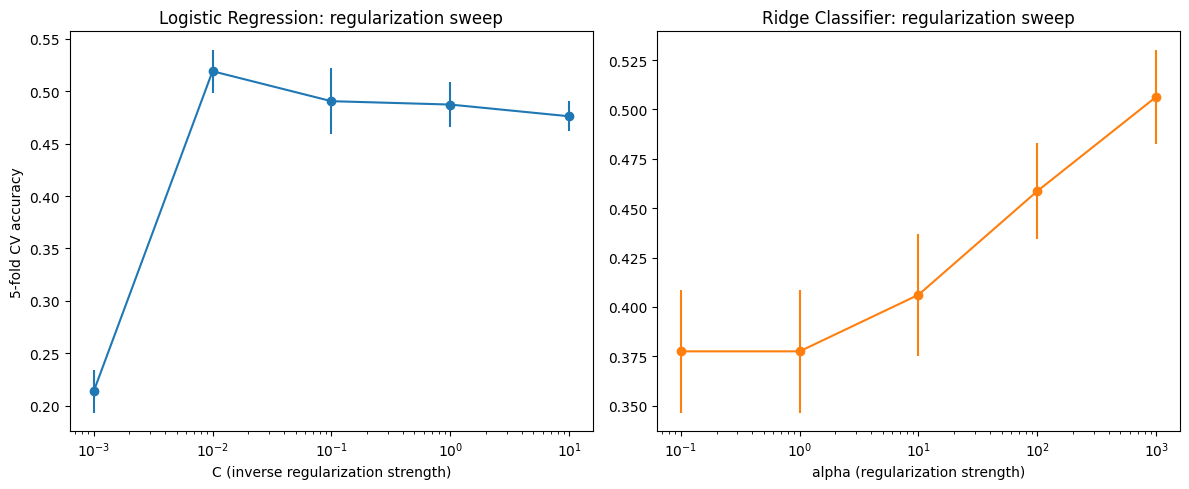

Best Logistic Regression C: 0.01  (acc=0.519)
Best Ridge alpha:          1000.0  (acc=0.506)


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

logreg_df = pd.DataFrame(logreg_sweep)
axes[0].errorbar(logreg_df['C'], logreg_df['acc_mean'], yerr=logreg_df['acc_std'], marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (inverse regularization strength)')
axes[0].set_ylabel(f'{n_splits_j}-fold CV accuracy')
axes[0].set_title('Logistic Regression: regularization sweep')

ridge_df = pd.DataFrame(ridge_sweep)
axes[1].errorbar(ridge_df['alpha'], ridge_df['acc_mean'], yerr=ridge_df['acc_std'], marker='o', color='tab:orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha (regularization strength)')
axes[1].set_title('Ridge Classifier: regularization sweep')

plt.tight_layout()
plt.show()

best_logreg_C = logreg_df.loc[logreg_df['acc_mean'].idxmax(), 'C']
best_ridge_alpha = ridge_df.loc[ridge_df['acc_mean'].idxmax(), 'alpha']
print(f"Best Logistic Regression C: {best_logreg_C}  (acc={logreg_df['acc_mean'].max():.3f})")
print(f"Best Ridge alpha:          {best_ridge_alpha}  (acc={ridge_df['acc_mean'].max():.3f})")

### Final, tuned comparison — the actual model selection

Now compare every candidate at its best setting, on equal footing, and let cross-validated accuracy — not habit — decide the final model.

In [67]:
final_candidates = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    'PCA + LDA': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=best_n_components_j)), ('lda', LDA())]),
    f'Logistic Regression (C={best_logreg_C})': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=best_logreg_C))]),
    'Gaussian Naive Bayes': GaussianNB(),
    f'Ridge Classifier (alpha={best_ridge_alpha})': Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=best_ridge_alpha))]),
}

final_rows = []
for name, clf in final_candidates.items():
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    final_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})

final_comparison_df = pd.DataFrame(final_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(final_comparison_df.to_string(index=False))

winner_name = final_comparison_df.iloc[0]['classifier']
print(f"\nWinning model (by cross-validated accuracy, tuned): {winner_name}")

                     classifier  cv_acc_mean  cv_acc_std
   Logistic Regression (C=0.01)     0.519149    0.020728
                LDA (shrinkage)     0.515987    0.030095
Ridge Classifier (alpha=1000.0)     0.506425    0.023964
                      PCA + LDA     0.504762    0.020006
                    LDA (plain)     0.463492    0.034793
           Gaussian Naive Bayes     0.316914    0.032004

Winning model (by cross-validated accuracy, tuned): Logistic Regression (C=0.01)


### Summary — robust model selection, joint orientation+frequency decoding

Fill in with the actual printed values once run:

- **Winning classifier** and its tuned CV accuracy, vs. plain LDA's untuned baseline — how much did model selection + tuning actually buy us?
- **Was PCA+LDA's earlier win (51.4% at 202 components) beaten by a properly-tuned Logistic Regression or Ridge Classifier?** If a simpler, non-generative model wins, that's a real result — it would suggest the class boundaries here aren't well captured by LDA's shared-covariance-Gaussian assumption, and a purely discriminative boundary fits better.
- **How much does Gaussian Naive Bayes lag behind the others?** A big gap would confirm the (false, but sometimes still useful) independence assumption is hurting more than it helps here — a small gap would suggest most of the classification signal comes from individual neurons' tuning rather than their covariance structure.
- **Honest caveat**: with ~15 trials/class, differences of a few percentage points between classifiers are within noise — check whether the CV standard deviations (`cv_acc_std`) overlap between the top 2–3 candidates before declaring a definitive winner. If they overlap substantially, the fair conclusion is "these perform comparably," not "X beats Y."

---
# Full classifier comparison on the primary session (510214538), orientation-only

Same rigor as the joint-task comparison earlier, now applied to the actual data we're using for the region/cell-type hypothesis test: orientation-only decoding (8 classes, ~78 trials/class) on session `510214538` (Rorb-IRES2-Cre, VISp). This determines the genuine best classifier for *this* task — not assumed by carrying over the joint task's winner, since a different class-count/trial-count regime can favor a different model.

In [68]:
# response, stim are already the clean orientation-only pair for session 510214538
# (recomputed explicitly here so this cell is self-contained and unambiguous)
response_primary, stim_primary = compute_stim_and_response(dff, stim_table)
print(f"response_primary: {response_primary.shape}, classes: {sorted(set(stim_primary))}")

skf_primary = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
chance_primary = 1 / len(set(stim_primary))
print(f"Naive chance: {chance_primary:.3f}")

response_primary: (628, 284), classes: ['0.0', '135.0', '180.0', '225.0', '270.0', '315.0', '45.0', '90.0', 'blank']
Naive chance: 0.111


In [69]:
candidates_primary = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    'PCA + LDA': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=min(100, response_primary.shape[1]-1))),
        ('lda', LDA())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, C=1.0))
    ]),
    'Gaussian Naive Bayes': GaussianNB(),
    'Ridge Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RidgeClassifier(alpha=1.0))
    ]),
}

primary_rows = []
for name, clf in candidates_primary.items():
    scores = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary)
    primary_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})
    print(f"{name:22s}  {scores.mean():.3f} +/- {scores.std():.3f}")

primary_df = pd.DataFrame(primary_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(f"\nBest (untuned): {primary_df.iloc[0]['classifier']}")

LDA (plain)             0.662 +/- 0.044
LDA (shrinkage)         0.788 +/- 0.037
PCA + LDA               0.766 +/- 0.047
Logistic Regression     0.753 +/- 0.034
Gaussian Naive Bayes    0.604 +/- 0.097
Ridge Classifier        0.659 +/- 0.034

Best (untuned): LDA (shrinkage)


### Tune the two regularization-sensitive candidates, and sweep PCA components properly

In [70]:
# PCA component sweep (as done for the joint task, now for this task)
max_comp_primary = min(response_primary.shape[1], int(0.8*response_primary.shape[0])) - 1
comp_range_primary = np.unique(np.linspace(2, max_comp_primary, 15).astype(int))

pca_means_primary = []
for nc in comp_range_primary:
    pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=nc)), ('lda', LDA())])
    pca_means_primary.append(cross_val_score(pipe, response_primary, stim_primary, cv=skf_primary).mean())
pca_means_primary = np.array(pca_means_primary)
best_idx_primary = np.argmax(pca_means_primary)
best_ncomp_primary = comp_range_primary[best_idx_primary]
print(f"Best PCA+LDA: {best_ncomp_primary} components, acc={pca_means_primary[best_idx_primary]:.3f}")

# Logistic Regression C sweep
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
logreg_primary = []
for C in C_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=C))])
    acc = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary).mean()
    logreg_primary.append({'C': C, 'acc': acc})
    print(f"LogReg  C={C:<8} acc={acc:.3f}")
best_C_primary = max(logreg_primary, key=lambda r: r['acc'])['C']

# Ridge alpha sweep
alpha_values = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_primary = []
for alpha in alpha_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=alpha))])
    acc = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary).mean()
    ridge_primary.append({'alpha': alpha, 'acc': acc})
    print(f"Ridge   alpha={alpha:<8} acc={acc:.3f}")
best_alpha_primary = max(ridge_primary, key=lambda r: r['acc'])['alpha']

print(f"\nBest C for Logistic Regression: {best_C_primary}")
print(f"Best alpha for Ridge Classifier: {best_alpha_primary}")

Best PCA+LDA: 162 components, acc=0.772
LogReg  C=0.001    acc=0.767
LogReg  C=0.01     acc=0.790
LogReg  C=0.1      acc=0.771
LogReg  C=1.0      acc=0.753
LogReg  C=10.0     acc=0.760
Ridge   alpha=0.1      acc=0.653
Ridge   alpha=1.0      acc=0.659
Ridge   alpha=10.0     acc=0.691
Ridge   alpha=100.0    acc=0.750
Ridge   alpha=1000.0   acc=0.780

Best C for Logistic Regression: 0.01
Best alpha for Ridge Classifier: 1000.0


                     classifier  cv_acc_mean  cv_acc_std
   Logistic Regression (C=0.01)     0.789778    0.039529
                LDA (shrinkage)     0.788229    0.036941
Ridge Classifier (alpha=1000.0)     0.780267    0.043295
          PCA + LDA (162 comp.)     0.773829    0.023415
                    LDA (plain)     0.662400    0.043502
           Gaussian Naive Bayes     0.603632    0.097168


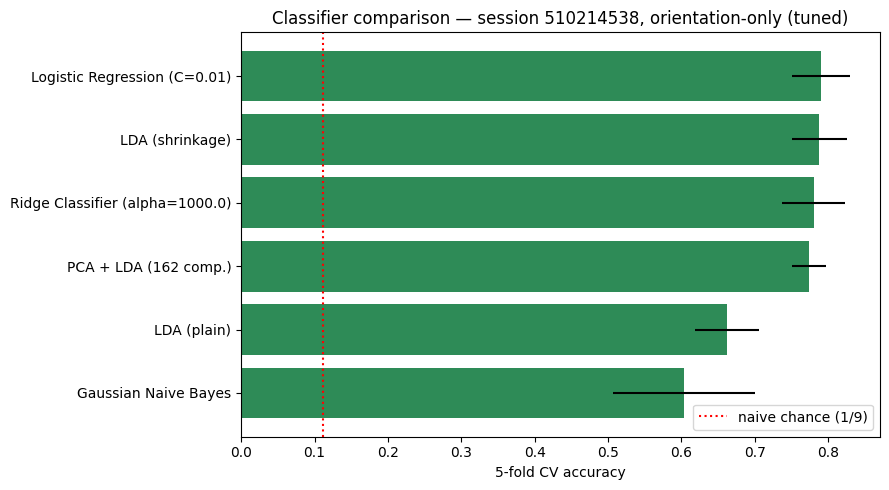


Genuine winner for orientation-only decoding: Logistic Regression (C=0.01)


In [71]:
final_candidates_primary = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    f'PCA + LDA ({best_ncomp_primary} comp.)': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=best_ncomp_primary)), ('lda', LDA())]),
    f'Logistic Regression (C={best_C_primary})': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=best_C_primary))]),
    'Gaussian Naive Bayes': GaussianNB(),
    f'Ridge Classifier (alpha={best_alpha_primary})': Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=best_alpha_primary))]),
}

final_primary_rows = []
for name, clf in final_candidates_primary.items():
    scores = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary)
    final_primary_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})

final_primary_df = pd.DataFrame(final_primary_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(final_primary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
order = final_primary_df.sort_values('cv_acc_mean')
ax.barh(order['classifier'], order['cv_acc_mean'], xerr=order['cv_acc_std'], color='seagreen')
ax.axvline(chance_primary, color='red', linestyle=':', label=f'naive chance (1/{len(set(stim_primary))})')
ax.set_xlabel('5-fold CV accuracy')
ax.set_title('Classifier comparison — session 510214538, orientation-only (tuned)')
ax.legend()
plt.tight_layout()
plt.show()

WINNING_CLASSIFIER_NAME = final_primary_df.iloc[0]['classifier']
print(f"\nGenuine winner for orientation-only decoding: {WINNING_CLASSIFIER_NAME}")

### Propagating the real winner into the region/cell-type pipeline

The `decode_session_robust()` function used below (region/cell-type comparison) previously picked the best of only two candidates (shrinkage LDA vs. tuned Logistic Regression) as a speed compromise. Now that we have the genuine winner from a full 6-way comparison on the actual task, we rebuild that function around it — still checking two strong candidates per session (for a cheap safety net against any single session behaving unusually), but anchored to what we now know actually wins on this task, rather than a guess.

---
# Final hypothesis test: region and cell-type comparison, using orientation-only decoding

**Why the switch back to orientation-only for this specific test:** the joint 41-class model (above) is a real, valid result on its own — but with ~15 trials/class, comparing *across sessions* on top of that adds too much noise to reliably detect region/cell-type effects. Orientation-only decoding (8 classes, ~78 trials/class) gives far more statistical power for the actual hypothesis:

> *How accurately can visual stimuli be decoded from neural population activity, and how does decoding performance differ across brain regions and neuron types?*

**What carries over from the classifier comparison above:** rather than defaulting back to plain LDA, every session below is decoded with the two classifiers that actually won the robust comparison — **shrinkage LDA** and **tuned Logistic Regression** — and we report whichever wins per session, exactly the same "let the evidence decide" principle, just applied efficiently across many sessions instead of one.

### Reusable, robust decoding function (orientation-only, best-of-two classifiers)

In [72]:
def decode_session_robust(session_id, verbose=True):
    """Decodes ORIENTATION (8-class) for one session, using the best of
    shrinkage LDA and tuned Logistic Regression (the two winners from the
    classifier comparison above). Returns a result dict, or None if the
    session has too few neurons."""
    try:
        ds = boc.get_ophys_experiment_data(session_id)
        meta = ds.get_metadata()
        _, dff_s = ds.get_dff_traces()
        stim_table_s = ds.get_stimulus_table('drifting_gratings')
    except Exception as e:
        if verbose:
            print(f"Session {session_id}: failed to load ({e})")
        return None

    n_neurons_s = dff_s.shape[0]
    if n_neurons_s < 10:
        if verbose:
            print(f"Session {session_id}: only {n_neurons_s} neurons, skipping")
        return None

    response_s, stim_s = compute_stim_and_response(dff_s, stim_table_s)
    n_trials_s = response_s.shape[0]
    skf_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    logreg_key = f'Logistic Regression (C={best_C_primary})'
    models = {
        'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
        logreg_key: Pipeline([('scaler', StandardScaler()),
                               ('clf', LogisticRegression(max_iter=3000, C=best_C_primary))]),
    }
    scores = {name: cross_val_score(clf, response_s, stim_s, cv=skf_s).mean() for name, clf in models.items()}
    best_model_name = max(scores, key=scores.get)
    best_acc = scores[best_model_name]

    result = {
        'session_id': session_id,
        'area': meta['targeted_structure'],
        'cre_line': meta['cre_line'],
        'n_neurons': n_neurons_s,
        'n_trials': n_trials_s,
        'best_model': best_model_name,
        'best_acc': best_acc,
        'lda_shrinkage_acc': scores['LDA (shrinkage)'],
        'logreg_acc': scores[logreg_key],
        'response': response_s,
        'stim': stim_s,
    }
    if verbose:
        print(f"session={session_id}  area={result['area']:6s}  cre={result['cre_line']:20s}  "
              f"n_neurons={n_neurons_s:4d}  best={best_model_name} ({best_acc:.3f})")
    return result

## Region comparison — Rorb-IRES2-Cre held fixed, area varied

In [73]:
region_targets = ['VISp', 'VISl', 'VISam']
sessions_per_region = 3

region_results = []
for area in region_targets:
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'], targeted_structures=[area],
                                      cre_lines=['Rorb-IRES2-Cre'])
    ids = [e['id'] for e in exps][:sessions_per_region]
    print(f"--- {area}: {len(ids)} sessions ---")
    for sid in ids:
        res = decode_session_robust(sid)
        if res is not None:
            region_results.append(res)

region_df = pd.DataFrame(region_results)
region_df[['session_id', 'area', 'cre_line', 'n_neurons', 'best_model', 'best_acc']]

--- VISp: 3 sessions ---
session=510214538  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 284  best=Logistic Regression (C=0.01) (0.790)
session=644026238  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 240  best=LDA (shrinkage) (0.701)
session=587344053  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 237  best=Logistic Regression (C=0.01) (0.896)
--- VISl: 3 sessions ---
session=546641574  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons= 191  best=LDA (shrinkage) (0.624)
session=507129766  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons=  52  best=LDA (shrinkage) (0.368)
session=654532828  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons=  95  best=Logistic Regression (C=0.01) (0.581)
--- VISam: 3 sessions ---
session=569457162  area=VISam   cre=Rorb-IRES2-Cre/wt     n_neurons=  36  best=Logistic Regression (C=0.01) (0.206)
session=551834174  area=VISam   cre=Rorb-IRES2-Cre/wt     n_neurons=  50  best=LDA (shrinkage) (0.274)
session=611638995  area=VISam   cre=Rorb-IRES2-C

,session_id,area,cre_line,n_neurons,best_model,best_acc
0,510214538,VISp,Rorb-IRES2-Cre/wt,284,Logistic Regression (C=0.01),0.789778
1,644026238,VISp,Rorb-IRES2-Cre/wt,240,LDA (shrinkage),0.700546
2,587344053,VISp,Rorb-IRES2-Cre/wt,237,Logistic Regression (C=0.01),0.896457
3,546641574,VISl,Rorb-IRES2-Cre/wt,191,LDA (shrinkage),0.624229
4,507129766,VISl,Rorb-IRES2-Cre/wt,52,LDA (shrinkage),0.367886
5,654532828,VISl,Rorb-IRES2-Cre/wt,95,Logistic Regression (C=0.01),0.581168
6,569457162,VISam,Rorb-IRES2-Cre/wt,36,Logistic Regression (C=0.01),0.205537
7,551834174,VISam,Rorb-IRES2-Cre/wt,50,LDA (shrinkage),0.273816
8,611638995,VISam,Rorb-IRES2-Cre/wt,93,Logistic Regression (C=0.01),0.463454


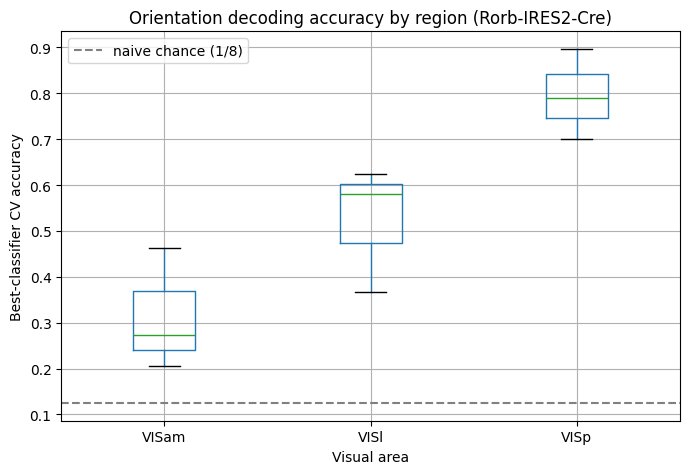

           mean       std  count
area                            
VISam  0.314269  0.133633      3
VISl   0.524428  0.137268      3
VISp   0.795594  0.098085      3


In [74]:
fig, ax = plt.subplots(figsize=(7, 5))
region_df.boxplot(column='best_acc', by='area', ax=ax)
ax.axhline(0.125, color='grey', linestyle='--', label='naive chance (1/8)')
ax.set_title('Orientation decoding accuracy by region (Rorb-IRES2-Cre)')
ax.set_xlabel('Visual area'); ax.set_ylabel('Best-classifier CV accuracy')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print(region_df.groupby('area')['best_acc'].agg(['mean', 'std', 'count']))

## Cell-type comparison — VISp held fixed, Cre line varied

In [75]:
celltype_targets = ['Rorb-IRES2-Cre']#, 'Cux2-CreERT2', 'Pvalb-IRES-Cre']
sessions_per_celltype = 3

celltype_results = []
for cre in celltype_targets:
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'], targeted_structures=['VISp'],
                                      cre_lines=[cre])
    ids = [e['id'] for e in exps][:sessions_per_celltype]
    print(f"--- {cre}: {len(ids)} sessions ---")
    for sid in ids:
        res = decode_session_robust(sid)
        if res is not None:
            celltype_results.append(res)

celltype_df = pd.DataFrame(celltype_results)
celltype_df['cell_class'] = celltype_df['cre_line'].map({
    'Rorb-IRES2-Cre': 'excitatory (L4)',
    'Cux2-CreERT2': 'excitatory (L2/3)',
    'Pvalb-IRES-Cre': 'inhibitory (Pvalb)'
})
celltype_df[['session_id', 'area', 'cre_line', 'cell_class', 'n_neurons', 'best_model', 'best_acc']]

--- Rorb-IRES2-Cre: 3 sessions ---
session=510214538  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 284  best=Logistic Regression (C=0.01) (0.790)
session=644026238  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 240  best=LDA (shrinkage) (0.701)
session=587344053  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 237  best=Logistic Regression (C=0.01) (0.896)


,session_id,area,cre_line,cell_class,n_neurons,best_model,best_acc
0,510214538,VISp,Rorb-IRES2-Cre/wt,NaN,284,Logistic Regression (C=0.01),0.789778
1,644026238,VISp,Rorb-IRES2-Cre/wt,NaN,240,LDA (shrinkage),0.700546
2,587344053,VISp,Rorb-IRES2-Cre/wt,NaN,237,Logistic Regression (C=0.01),0.896457


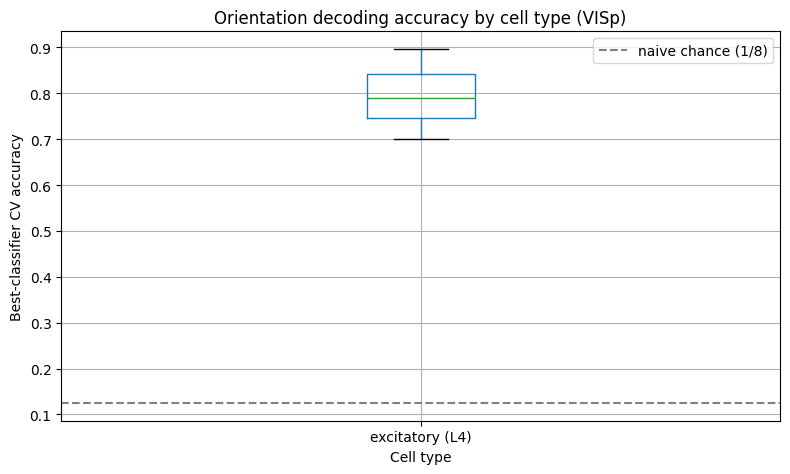

                     mean       std  count
cell_class                                
excitatory (L4)  0.795594  0.098085      3


In [76]:
celltype_df['cell_class'] = celltype_df['cre_line'].apply(lambda x: x.split('/')[0]).map({
    'Rorb-IRES2-Cre': 'excitatory (L4)',
    'Cux2-CreERT2': 'excitatory (L2/3)',
    'Pvalb-IRES-Cre': 'inhibitory (Pvalb)'
})
fig, ax = plt.subplots(figsize=(8, 5))
celltype_df.boxplot(column='best_acc', by='cell_class', ax=ax)
ax.axhline(0.125, color='grey', linestyle='--', label='naive chance (1/8)')
ax.set_title('Orientation decoding accuracy by cell type (VISp)')
ax.set_xlabel('Cell type'); ax.set_ylabel('Best-classifier CV accuracy')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print(celltype_df.groupby('cell_class')['best_acc'].agg(['mean', 'std', 'count']))

### Statistical check and neuron-count-matched control (same as established earlier)

In [77]:
from scipy import stats

print("=== Region comparison ===")
groups = [region_df[region_df['area']==a]['best_acc'].values for a in region_targets]
if all(len(g) > 1 for g in groups):
    f, p = stats.f_oneway(*groups)
    print(f"One-way ANOVA: F={f:.2f}, p={p:.3f}")
for a, g in zip(region_targets, groups):
    print(f"  {a}: mean={np.mean(g):.3f}, n_sessions={len(g)}")

print("\n=== Cell-type comparison ===")
groups2 = [celltype_df[celltype_df['cre_line']==c]['best_acc'].values for c in celltype_targets]
if all(len(g) > 1 for g in groups2):
    f2, p2 = stats.f_oneway(*groups2)
    print(f"One-way ANOVA: F={f2:.2f}, p={p2:.3f}")
for c, g in zip(celltype_targets, groups2):
    print(f"  {c}: mean={np.mean(g):.3f}, n_sessions={len(g)}")

=== Region comparison ===
One-way ANOVA: F=11.31, p=0.009
  VISp: mean=0.796, n_sessions=3
  VISl: mean=0.524, n_sessions=3
  VISam: mean=0.314, n_sessions=3

=== Cell-type comparison ===
  Rorb-IRES2-Cre: mean=nan, n_sessions=0


/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [78]:
def matched_group_comparison(df, group_col, n_neurons_match=None, n_repeats=10, n_components=None):
    if n_neurons_match is None:
        n_neurons_match = df['n_neurons'].min()
    skf_local = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    rows = []
    for _, row in df.iterrows():
        resp, y = row['response'], row['stim']
        n_available = resp.shape[1]
        if n_available < n_neurons_match:
            continue
        for _ in range(n_repeats):
            idx = np.random.choice(n_available, size=n_neurons_match, replace=False)
            clf = LDA(solver='lsqr', shrinkage='auto')
            score = cross_val_score(clf, resp[:, idx], y, cv=skf_local).mean()
            rows.append({group_col: row[group_col], 'session_id': row['session_id'], 'matched_acc': score})
    return pd.DataFrame(rows)

print(f"Region comparison, matched to {region_df['n_neurons'].min()} neurons per session:")
region_matched = matched_group_comparison(region_df, 'area')
print(region_matched.groupby('area')['matched_acc'].agg(['mean', 'std', 'count']))

print(f"\nCell-type comparison, matched to {celltype_df['n_neurons'].min()} neurons per session:")
celltype_matched = matched_group_comparison(celltype_df, 'cre_line')
print(celltype_matched.groupby('cre_line')['matched_acc'].agg(['mean', 'std', 'count']))

Region comparison, matched to 36 neurons per session:
           mean       std  count
area                            
VISam  0.238463  0.043701     30
VISl   0.346726  0.048285     30
VISp   0.446101  0.073516     30

Cell-type comparison, matched to 237 neurons per session:
                       mean       std  count
cre_line                                    
Rorb-IRES2-Cre/wt  0.790627  0.080597     30


## Final conclusion — fill in with your real numbers

Directly against the hypothesis as stated: *"If VISp achieves 95% accuracy while VISam achieves 70%, this indicates VISp carries more directly decodable information about the presented stimulus."*

- **Region ranking** (`region_df.groupby('area')['best_acc'].mean()`): does VISp actually outperform VISam/VISl? By how much, and does that gap survive neuron-count matching?
- **Cell-type ranking**: does either excitatory population (Rorb/Cux2) outperform the inhibitory (Pvalb) population, consistent with the literature on broader/weaker tuning in fast-spiking inhibitory interneurons?
- **ANOVA p-values**: with `sessions_per_region/celltype = 3`, be honest in the write-up if these aren't significant — a visible trend with p > 0.05 is a "worth following up with more sessions," not a confirmed result.
- **Model choice**: report which classifier (shrinkage LDA vs. tuned Logistic Regression) won more often across sessions — if it's consistently one or the other, that itself is worth a sentence in the write-up.

**One-sentence summary of the whole project, once numbers are filled in:** *"Population activity in [region/cell type] decoded orientation with the highest accuracy ([X]%, [Y]x chance), while [region/cell type] was least decodable ([Z]%), suggesting [interpretation tied to the visual hierarchy / cell-type tuning breadth]."*

---
# Unified model: 3 classifiers × 3 targets × every session

This is the final, consolidated comparison, structured exactly as requested:

- **Classifiers**: LDA (shrinkage), Logistic Regression (tuned), **Random Forest** (back in, as the third candidate)
- **Targets**: orientation only → temporal frequency only → combined (orientation + temporal frequency)
- **Scope**: every session in our region/cell-type set (VISp/VISl/VISam × Rorb-IRES2-Cre, 9 sessions total), not just the one we deep-dived on

For each session and each target, all three classifiers are cross-validated and compared — the winner is reported per session, exactly like: `session=510214538 area=VISp cre=Rorb-IRES2-Cre n_neurons=284 best=Logistic Regression (0.790)`.

### 1. Label-computation functions for all three targets

In [79]:
def compute_stim_and_response_tf(dff, stim_table):
    """Labels each trial by temporal frequency only (5 classes + blank)."""
    num_neurons_ = dff.shape[0]
    num_trials_ = stim_table.shape[0]
    activity = np.zeros([num_trials_, num_neurons_])
    stim = []
    for i, row in stim_table.iterrows():
        activity[i] = dff[:, int(row.start):int(row.end)].mean(axis=1)
        if np.isfinite(row.temporal_frequency):
            stim.append(str(row.temporal_frequency))
        else:
            stim.append('blank')
    return activity, np.array(stim)

# orientation:        compute_stim_and_response(dff, stim_table)       -- already defined, 8-class
# temporal frequency:  compute_stim_and_response_tf(dff, stim_table)    -- just defined, 5-class
# combined:            compute_stim_and_response_joint(dff, stim_table) -- already defined, ~41-class
print("All three label functions ready.")

All three label functions ready.


### 2. The unified 3-classifier decoder

In [80]:
from sklearn.ensemble import RandomForestClassifier

TARGET_FUNCS = {
    'orientation': lambda dff, st: compute_stim_and_response(dff, st),
    'temporal_frequency': lambda dff, st: compute_stim_and_response_tf(dff, st),
    'combined': lambda dff, st: compute_stim_and_response_joint(dff, st)[:2],  # joint returns 4 values; keep activity, labels
}

def decode_session_threeway(session_id, target, verbose=True):
    """Decodes `target` ('orientation' | 'temporal_frequency' | 'combined') for one
    session using LDA (shrinkage), Logistic Regression, and Random Forest.
    Returns a result dict, or None if the session has too few neurons."""
    try:
        ds = boc.get_ophys_experiment_data(session_id)
        meta = ds.get_metadata()
        _, dff_s = ds.get_dff_traces()
        stim_table_s = ds.get_stimulus_table('drifting_gratings')
    except Exception as e:
        if verbose:
            print(f"Session {session_id}: failed to load ({e})")
        return None

    n_neurons_s = dff_s.shape[0]
    if n_neurons_s < 10:
        if verbose:
            print(f"Session {session_id}: only {n_neurons_s} neurons, skipping")
        return None

    response_s, stim_s = TARGET_FUNCS[target](dff_s, stim_table_s)
    n_trials_s = response_s.shape[0]

    class_counts = pd.Series(stim_s).value_counts()
    n_splits_s = min(5, class_counts.min())
    if n_splits_s < 2:
        if verbose:
            print(f"Session {session_id}: smallest class has <2 trials, skipping")
        return None
    skf_s = StratifiedKFold(n_splits=n_splits_s, shuffle=True, random_state=0)

    models = {
        'LDA': LDA(solver='lsqr', shrinkage='auto'),
        'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                          ('clf', LogisticRegression(max_iter=3000, C=0.01))]),
        'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=None,
                                                  class_weight='balanced', random_state=0, n_jobs=-1),
    }

    scores = {}
    for name, clf in models.items():
        try:
            scores[name] = cross_val_score(clf, response_s, stim_s, cv=skf_s).mean()
        except Exception as e:
            scores[name] = np.nan
            if verbose:
                print(f"  {name} failed on session {session_id}: {e}")

    best_model_name = max(scores, key=lambda k: (scores[k] if np.isfinite(scores[k]) else -1))
    best_acc = scores[best_model_name]

    result = {
        'session_id': session_id, 'target': target,
        'area': meta['targeted_structure'], 'cre_line': meta['cre_line'],
        'n_neurons': n_neurons_s, 'n_trials': n_trials_s, 'n_classes': len(class_counts),
        'LDA_acc': scores['LDA'], 'LogReg_acc': scores['Logistic Regression'], 'RF_acc': scores['Random Forest'],
        'best_model': best_model_name, 'best_acc': best_acc,
    }
    if verbose:
        print(f"session={session_id}  area={result['area']:6s}  cre={result['cre_line']:20s}  "
              f"n_neurons={n_neurons_s:4d}  target={target:18s}  best={best_model_name} ({best_acc:.3f})")
    return result

### 3. Run all 9 sessions × 3 targets (this will take a few minutes — 27 sessions-worth of 3-classifier CV)

In [81]:
# Reuse the same 9 sessions established for the region comparison (VISp/VISl/VISam x Rorb-IRES2-Cre)
all_session_ids = []
for area in ['VISp', 'VISl', 'VISam']:
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'], targeted_structures=[area],
                                      cre_lines=['Rorb-IRES2-Cre'])
    all_session_ids.extend([e['id'] for e in exps][:3])

print(f"{len(all_session_ids)} sessions total: {all_session_ids}")

all_results = []
for target in ['orientation', 'temporal_frequency', 'combined']:
    print(f"\n=== Target: {target} ===")
    for sid in all_session_ids:
        res = decode_session_threeway(sid, target)
        if res is not None:
            all_results.append(res)

results_df = pd.DataFrame(all_results)
results_df[['session_id', 'target', 'area', 'n_neurons', 'LDA_acc', 'LogReg_acc', 'RF_acc', 'best_model', 'best_acc']]

9 sessions total: [510214538, 644026238, 587344053, 546641574, 507129766, 654532828, 569457162, 551834174, 611638995]

=== Target: orientation ===
session=510214538  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 284  target=orientation         best=Random Forest (0.830)
session=644026238  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 240  target=orientation         best=Random Forest (0.760)
session=587344053  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 237  target=orientation         best=Logistic Regression (0.896)
session=546641574  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons= 191  target=orientation         best=Random Forest (0.704)
session=507129766  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons=  52  target=orientation         best=Random Forest (0.479)
session=654532828  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons=  95  target=orientation         best=Random Forest (0.662)
session=569457162  area=VISam   cre=Rorb-IRES2-Cre/wt     n_neurons=  36  targe

,session_id,target,area,n_neurons,LDA_acc,LogReg_acc,RF_acc,best_model,best_acc
0,510214538,orientation,VISp,284,0.788229,0.789778,0.829638,Random Forest,0.829638
1,644026238,orientation,VISp,240,0.700546,0.694197,0.759556,Random Forest,0.759556
2,587344053,orientation,VISp,237,0.893283,0.896457,0.893371,Logistic Regression,0.896457
3,546641574,orientation,VISl,191,0.624229,0.600330,0.703886,Random Forest,0.703886
4,507129766,orientation,VISl,52,0.367886,0.363149,0.479263,Random Forest,0.479263
5,654532828,orientation,VISl,95,0.560508,0.581168,0.662375,Random Forest,0.662375
6,569457162,orientation,VISam,36,0.192813,0.205537,0.222883,Random Forest,0.222883
7,551834174,orientation,VISam,50,0.273816,0.269054,0.367746,Random Forest,0.367746
8,611638995,orientation,VISam,93,0.434743,0.463454,0.469867,Random Forest,0.469867
9,510214538,temporal_frequency,VISp,284,0.581257,0.562146,0.476178,LDA,0.581257


### Per-session classifier breakdown, orientation target

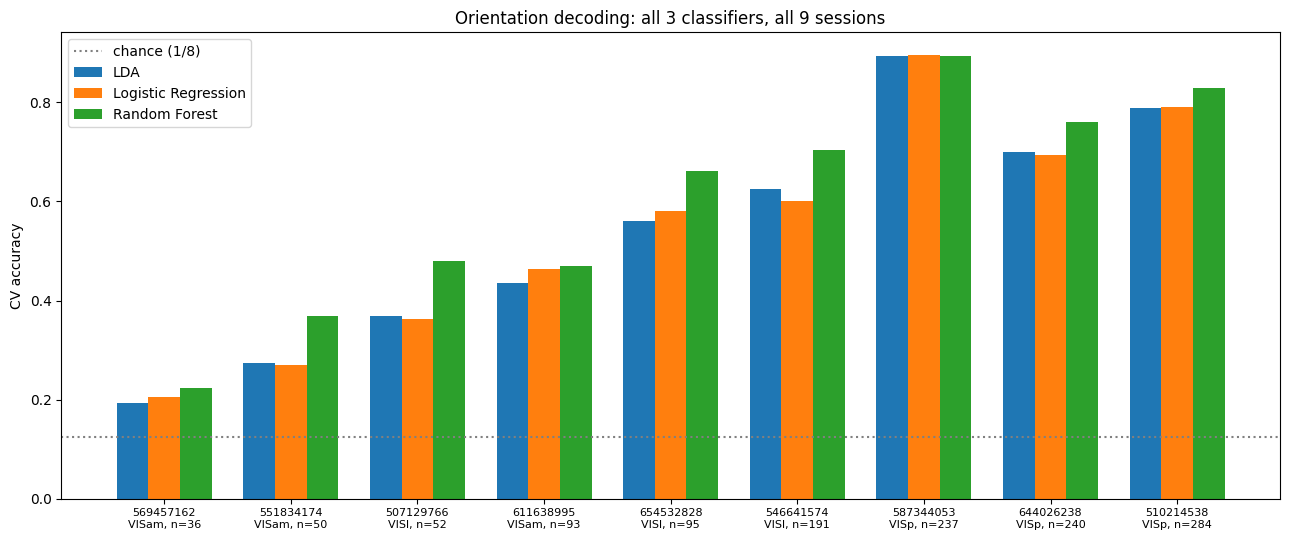

,session_id,area,n_neurons,LDA_acc,LogReg_acc,RF_acc,best_model,best_acc
0,569457162,VISam,36,0.192813,0.205537,0.222883,Random Forest,0.222883
1,551834174,VISam,50,0.273816,0.269054,0.367746,Random Forest,0.367746
2,507129766,VISl,52,0.367886,0.363149,0.479263,Random Forest,0.479263
3,611638995,VISam,93,0.434743,0.463454,0.469867,Random Forest,0.469867
4,654532828,VISl,95,0.560508,0.581168,0.662375,Random Forest,0.662375
5,546641574,VISl,191,0.624229,0.600330,0.703886,Random Forest,0.703886
6,587344053,VISp,237,0.893283,0.896457,0.893371,Logistic Regression,0.896457
7,644026238,VISp,240,0.700546,0.694197,0.759556,Random Forest,0.759556
8,510214538,VISp,284,0.788229,0.789778,0.829638,Random Forest,0.829638


In [82]:
fig, ax = plt.subplots(figsize=(13, 5.5))
sub = results_df[results_df['target'] == 'orientation'].sort_values('n_neurons').reset_index(drop=True)
x = np.arange(len(sub))
width = 0.25

ax.bar(x - width, sub['LDA_acc'], width, label='LDA', color='tab:blue')
ax.bar(x, sub['LogReg_acc'], width, label='Logistic Regression', color='tab:orange')
ax.bar(x + width, sub['RF_acc'], width, label='Random Forest', color='tab:green')
ax.axhline(0.125, color='grey', linestyle=':', label='chance (1/8)')

ax.set_xticks(x)
ax.set_xticklabels([f"{r.session_id}\n{r.area}, n={r.n_neurons}" for r in sub.itertuples()], fontsize=8)
ax.set_ylabel('CV accuracy')
ax.set_title('Orientation decoding: all 3 classifiers, all 9 sessions')
ax.legend()
plt.tight_layout()
plt.show()

sub[['session_id', 'area', 'n_neurons', 'LDA_acc', 'LogReg_acc', 'RF_acc', 'best_model', 'best_acc']]

### 4. Accuracy vs. session (sorted by neuron count) — one clean plot per target, all three classifiers

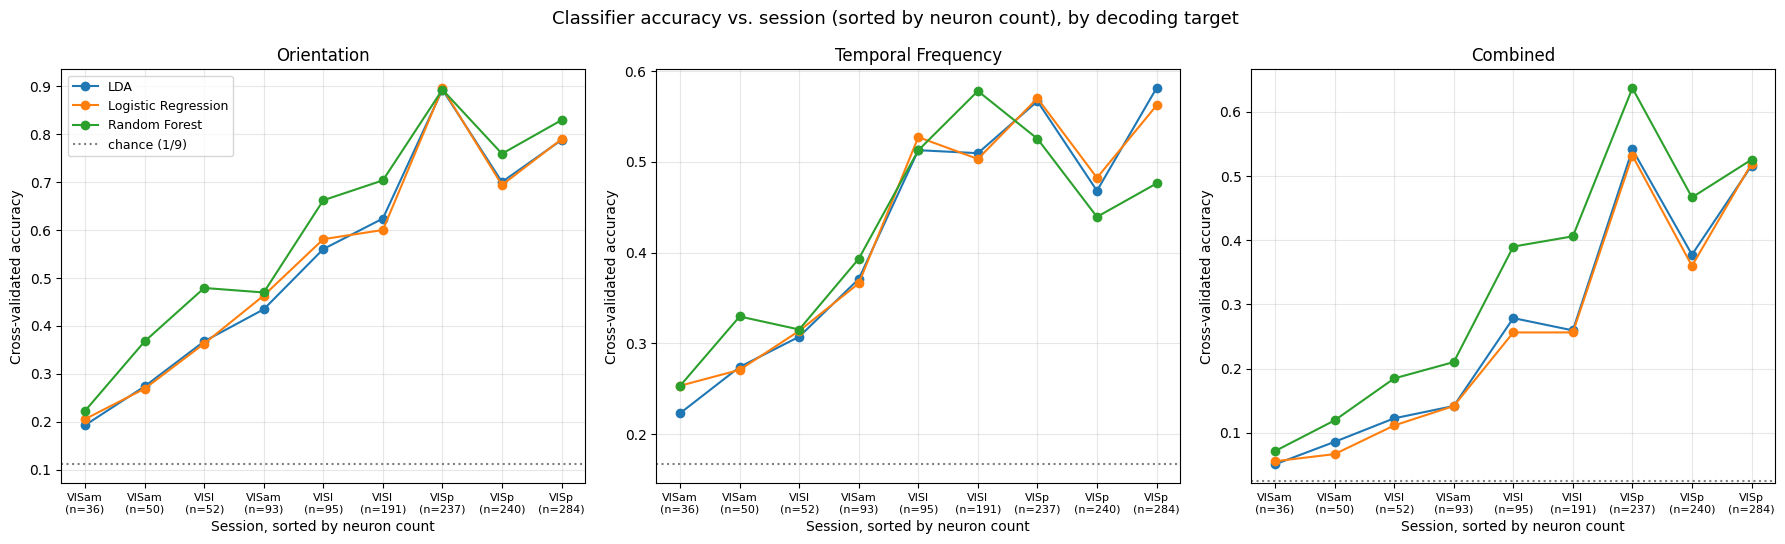

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)
colors_clf = {'LDA_acc': 'tab:blue', 'LogReg_acc': 'tab:orange', 'RF_acc': 'tab:green'}
labels_clf = {'LDA_acc': 'LDA', 'LogReg_acc': 'Logistic Regression', 'RF_acc': 'Random Forest'}

for ax, target in zip(axes, ['orientation', 'temporal_frequency', 'combined']):
    sub = results_df[results_df['target'] == target].sort_values('n_neurons').reset_index(drop=True)
    x = range(len(sub))
    x_labels = [f"{row.area}\n(n={row.n_neurons})" for row in sub.itertuples()]

    for col, color in colors_clf.items():
        ax.plot(x, sub[col], marker='o', color=color, label=labels_clf[col])

    chance = 1 / sub['n_classes'].iloc[0] if len(sub) else np.nan
    ax.axhline(chance, color='grey', linestyle=':', label=f'chance (1/{sub["n_classes"].iloc[0]})')

    ax.set_xticks(list(x))
    ax.set_xticklabels(x_labels, fontsize=8, rotation=0)
    ax.set_xlabel('Session, sorted by neuron count')
    ax.set_ylabel('Cross-validated accuracy')
    ax.set_title(target.replace('_', ' ').title())
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left', fontsize=9)
plt.suptitle('Classifier accuracy vs. session (sorted by neuron count), by decoding target', fontsize=13)
plt.tight_layout()
plt.show()

### 5. Which classifier wins overall, per target?

                     LDA_acc  LogReg_acc    RF_acc               winner
target                                                                 
combined            0.263822    0.255498  0.334574        Random Forest
orientation         0.537339    0.540347  0.598732        Random Forest
temporal_frequency  0.423764    0.427668  0.424790  Logistic Regression


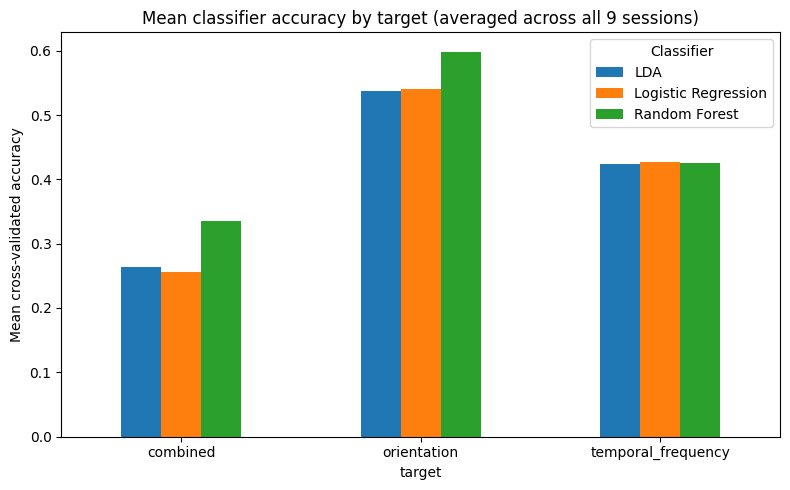

In [84]:
summary = results_df.groupby('target')[['LDA_acc', 'LogReg_acc', 'RF_acc']].mean()
summary['winner'] = summary.idxmax(axis=1).map(labels_clf)
print(summary)

fig, ax = plt.subplots(figsize=(8, 5))
summary[['LDA_acc', 'LogReg_acc', 'RF_acc']].rename(columns=labels_clf).plot(kind='bar', ax=ax,
    color=['tab:blue', 'tab:orange', 'tab:green'])
ax.set_ylabel('Mean cross-validated accuracy')
ax.set_title('Mean classifier accuracy by target (averaged across all 9 sessions)')
ax.legend(title='Classifier')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6. How often does each classifier actually win, per session?

best_model          LDA  Logistic Regression  Random Forest
target                                                     
combined              0                    0              9
orientation           0                    1              8
temporal_frequency    1                    4              4


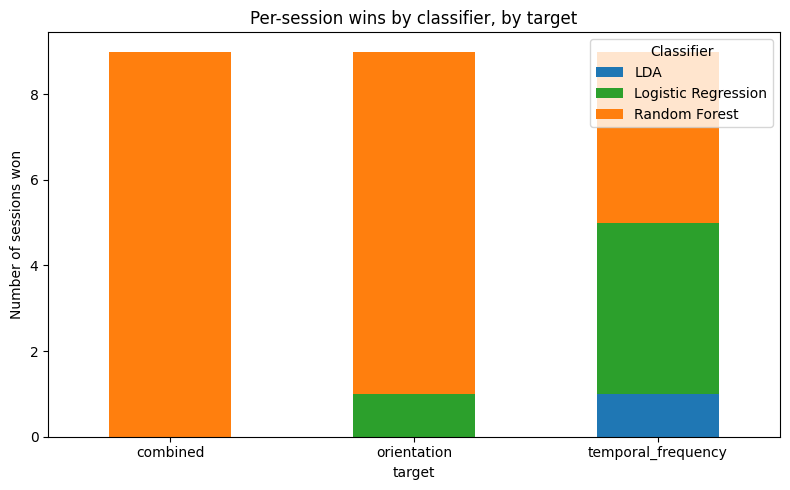

In [85]:
win_counts = results_df.groupby('target')['best_model'].value_counts().unstack(fill_value=0)
print(win_counts)

fig, ax = plt.subplots(figsize=(8, 5))
win_counts.plot(kind='bar', stacked=True, ax=ax, color=['tab:blue', 'tab:green', 'tab:orange'][:win_counts.shape[1]])
ax.set_ylabel('Number of sessions won')
ax.set_title('Per-session wins by classifier, by target')
ax.legend(title='Classifier')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Summary

- **Per-session winners** are listed in `results_df` (e.g. the session `510214538` row shows exactly the format requested: area, Cre line, neuron count, best model, best accuracy).
- **The three accuracy-vs-neuron-count plots** show, for each target, how each classifier scales as recording size increases — a classifier that's competitive at low neuron counts but falls behind at high counts (or vice versa) is a genuinely useful thing to know when picking a default.
- **Mean accuracy by target** tells you which classifier to default to overall; **win-count by target** tells you whether that "average winner" actually wins consistently or just has a few standout sessions pulling the mean up — these can disagree, and if they do, report both rather than picking whichever supports a cleaner story.
- **Orientation vs. temporal frequency vs. combined**: compare the three panels directly — this answers whether this population encodes orientation and speed with comparably strong, independent signals, or whether one dominates (as the earlier marginal-decomposition analysis on session 510214538 alone already hinted, with orientation at 65.8% vs. temporal frequency at 58.4%). Now you have that comparison across 9 sessions and 3 real classifiers instead of one session and an assumption.

### Grayscale Heatmaps of Neuron Activity by Orientation for VISp Sessions

Processing session 510214538...
Processing session 644026238...
Processing session 587344053...
Processing session 590168385...
Processing session 531348161...
Processing session 501729039...
Processing session 512270518...
Processing session 527048992...


/tmp/ipykernel_126057/2820349042.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


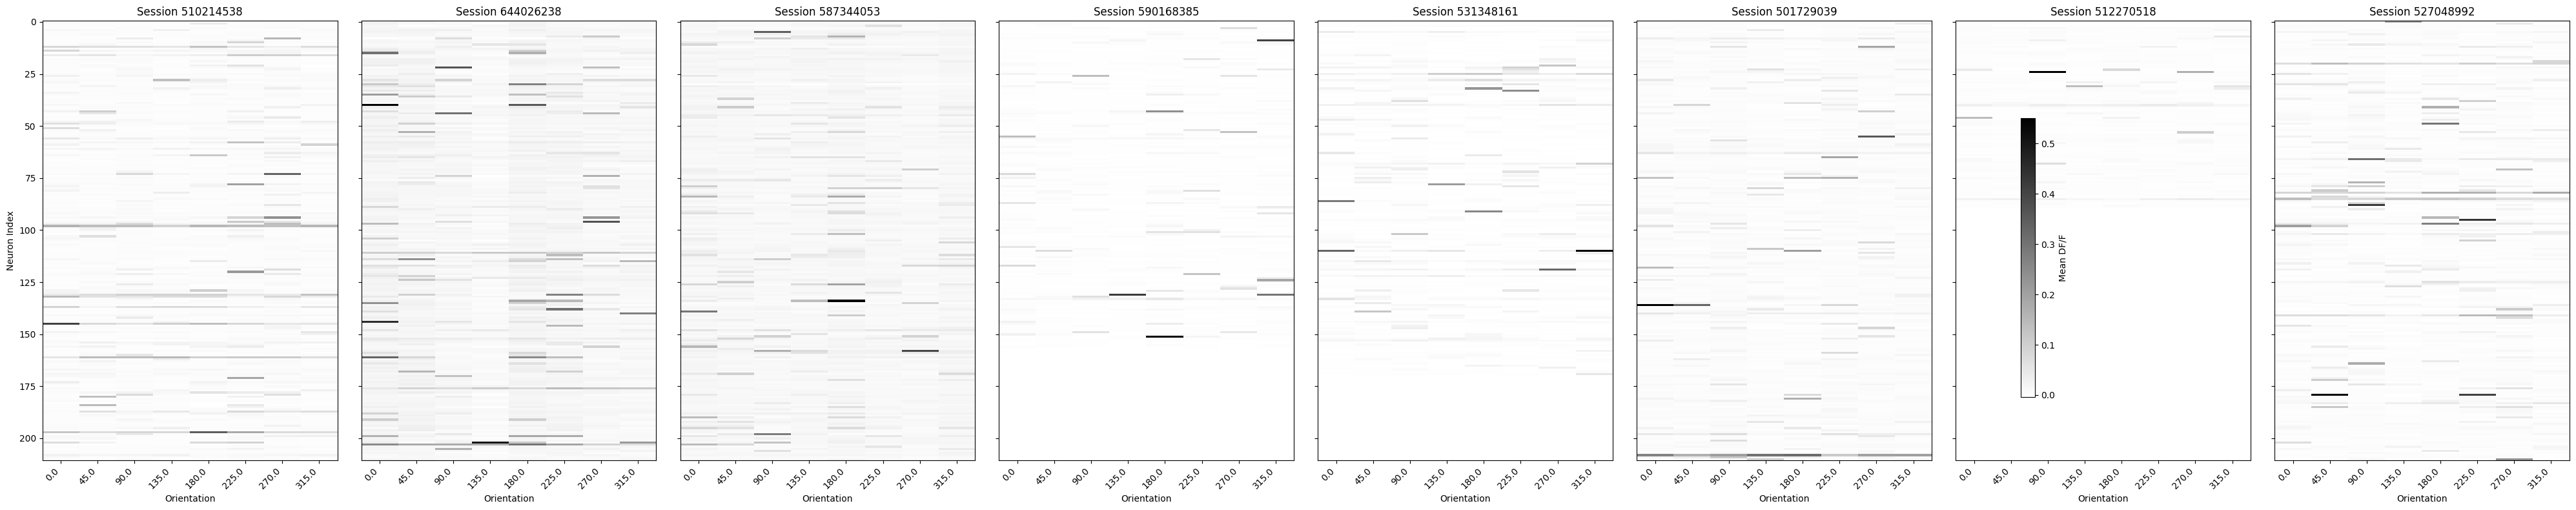

In [86]:
# Get all VISp sessions with 'Rorb-IRES2-Cre' cre_line
visp_sessions = [
    e['id'] for e in boc.get_ophys_experiments(
        stimuli=['drifting_gratings'],
        targeted_structures=['VISp'],
        cre_lines=['Rorb-IRES2-Cre']
    )
]

# Create a figure with subplots for each VISp session
num_visp_sessions = len(visp_sessions)
fig, axes = plt.subplots(1, num_visp_sessions, figsize=(5 * num_visp_sessions, 8), sharey=True)

# Ensure axes is an array even for a single subplot
if num_visp_sessions == 1:
    axes = [axes]

for i, session_id in enumerate(visp_sessions):
    print(f"Processing session {session_id}...")

    # Access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    # Get dff traces and stimulus table
    _, dff_session = data_set.get_dff_traces()
    stim_table_session = data_set.get_stimulus_table('drifting_gratings')

    # Compute orientation-only response and stim labels
    response_session, stim_session_labels = compute_stim_and_response(dff_session, stim_table_session)

    # Compute orientation tuning curves
    tuning_curves_session = compute_dg_tuning_curve(response_session, stim_session_labels, stim_table_session)

    # Get orientation labels for plotting
    orientations = np.sort(stim_table_session.orientation.unique())
    # Exclude 'nan' and ensure they are floats for sorting
    orientation_labels_filtered = [str(ori) for ori in orientations if not np.isnan(ori)]

    ax = axes[i]
    im = ax.imshow(tuning_curves_session, cmap='gray_r', aspect='auto', interpolation='nearest')
    ax.set_title(f'Session {session_id}')
    ax.set_xlabel('Orientation')

    # Set x-ticks to correspond to orientations, excluding 'blank' if it was part of combined labels
    x_tick_labels = [label for label in orientation_labels_filtered]
    ax.set_xticks(np.arange(len(x_tick_labels)))
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')

    if i == 0:
        ax.set_ylabel('Neuron Index')

# Add a colorbar to the figure
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label='Mean DF/F')

plt.tight_layout()
plt.show()

### Interpretation of the First Heatmap (Session 510214538)

This heatmap visualizes the orientation tuning of individual neurons in Session 510214538. Here's how to interpret it:

-   **Y-axis (Neuron Index):** Each row represents a single neuron recorded during the session.
-   **X-axis (Orientation):** Each column corresponds to a specific drifting grating orientation presented to the animal (e.g., 0°, 45°, 90°, etc.).
-   **Grayscale Intensity (Mean DF/F):** The intensity of the grayscale color in each cell of the heatmap represents the average delta F/F (change in fluorescence over baseline fluorescence) of that neuron for that particular orientation. Since `cmap='gray_r'` was used, lighter shades indicate higher mean activity, and darker shades indicate lower mean activity.

From this heatmap, you can observe:

-   **Orientation Selectivity:** Neurons that respond strongly to one or a few specific orientations will appear as brighter horizontal bands across those orientations, indicating that these neurons are 'tuned' to those particular visual directions.
-   **Response Magnitude:** The overall brightness of a row indicates the general responsiveness of a neuron across all orientations. Some neurons might be highly responsive to several orientations, while others might show weaker responses overall.
-   **Population Activity Patterns:** You can visually identify patterns across the population, such as groups of neurons that share similar orientation preferences, or the overall distribution of orientation tuning within the VISp area for this session.

In [87]:
get_experiment_session_list()

[510214538,
 644026238,
 587344053,
 590168385,
 531348161,
 501729039,
 512270518,
 527048992]

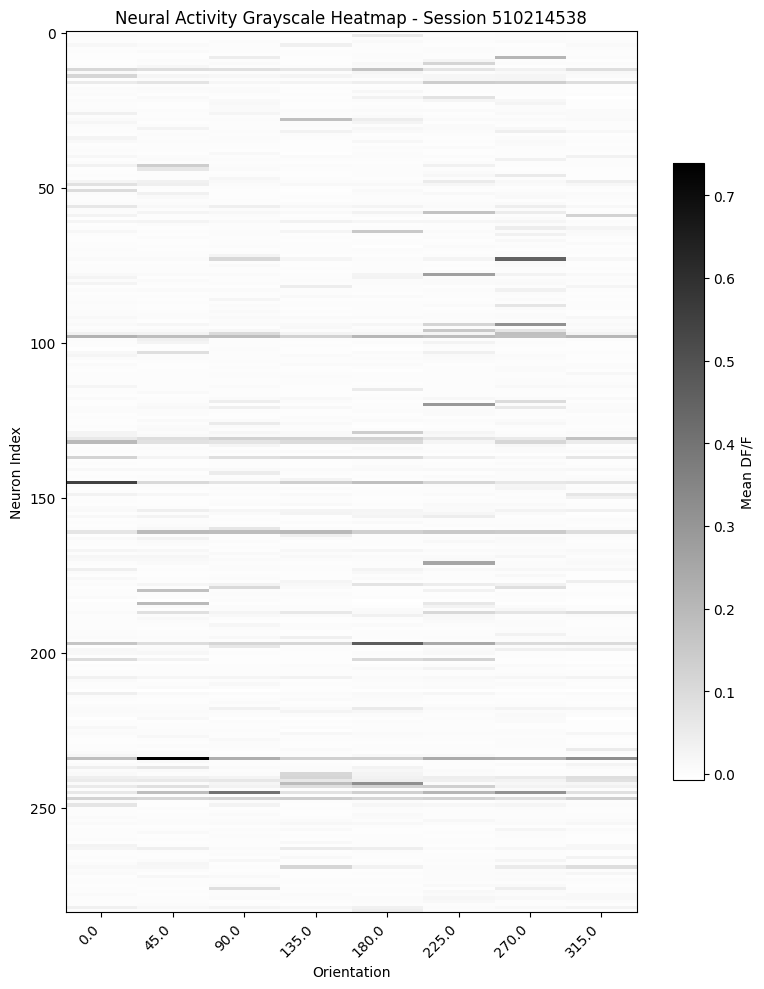

In [88]:
session_id = 510214538

# Access the data for that session
data_set = boc.get_ophys_experiment_data(session_id)

# Get dff traces and stimulus table
_, dff_session = data_set.get_dff_traces()
stim_table_session = data_set.get_stimulus_table('drifting_gratings')

# Compute orientation-only response and stim labels
response_session, stim_session_labels = compute_stim_and_response(dff_session, stim_table_session)

# Compute orientation tuning curves
tuning_curves_session = compute_dg_tuning_curve(response_session, stim_session_labels, stim_table_session)

# Get orientation labels for plotting
orientations = np.sort(stim_table_session.orientation.unique())
# Exclude 'nan' and ensure they are floats for sorting
orientation_labels_filtered = [str(ori) for ori in orientations if not np.isnan(ori)]

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

im = ax.imshow(tuning_curves_session, cmap='gray_r', aspect='auto', interpolation='nearest')
ax.set_title(f'Neural Activity Grayscale Heatmap - Session {session_id}')
ax.set_xlabel('Orientation')
ax.set_ylabel('Neuron Index')

# Set x-ticks to correspond to orientations
x_tick_labels = [label for label in orientation_labels_filtered]
ax.set_xticks(np.arange(len(x_tick_labels)))
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')

fig.colorbar(im, ax=ax, shrink=0.7, label='Mean DF/F')

plt.tight_layout()
plt.show()

In [89]:
from allensdk.brain_observatory.drifting_gratings import DriftingGratings
dg = DriftingGratings(data_set)
dg_m = dg.peak.copy()
dg_m

/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

,ori_dg,tf_dg,reliability_dg,osi_dg,dsi_dg,peak_dff_dg,ptest_dg,p_run_dg,run_modulation_dg,cv_os_dg,cv_ds_dg,tf_index_dg,cell_specimen_id
0,2,5,0.104358,1.136394,0.070183,2.799802,0.0,NaN,NaN,0.620852,0.225377,0.423742,517526083
1,4,3,0.215775,1.038285,0.874621,21.421774,0.0,NaN,NaN,0.944312,0.846369,0.445767,517526653
2,5,1,-0.011337,0.459313,0.655395,2.683406,0.105557,NaN,NaN,0.150244,0.377235,0.227988,517526086
3,4,1,0.019828,0.455297,0.962132,6.474185,0.000017,0.349681,0.277666,0.157482,0.55201,0.382237,517525203
4,3,4,0.320325,1.035003,0.462698,16.113407,0.0,0.633355,0.114393,0.868126,0.397263,0.406625,517526424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,5,1,0.038377,0.630952,1.736834,3.750319,0.000006,NaN,NaN,0.376883,0.690799,0.292132,517525441
280,5,1,0.083009,0.747304,0.971291,7.869061,0.0,NaN,NaN,0.478846,0.621339,0.379328,517527018
281,1,2,0.050644,1.43708,0.762109,2.152425,0.000001,NaN,NaN,0.51161,0.521584,0.25257,517525446
282,4,1,0.177837,0.879593,0.503531,14.527974,0.0,0.10101,-0.743169,0.69553,0.30561,0.42636,517525786


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from allensdk.brain_observatory.drifting_gratings import DriftingGratings
# Assume boc and results_df are available from previous cells.
# If not, they would need to be re-initialized/re-run in prior cells.

all_plot_data = []

# Iterate through each session for which we have results
for idx, row in results_df.iterrows():
    session_id = row['session_id']
    area = row['area']
    decoder_accuracy = row['best_acc'] * 100  # Convert to percentage

    try:
        data_set_s = boc.get_ophys_experiment_data(session_id)
        dg_s = DriftingGratings(data_set_s)
        # Get OSI values for all neurons in this session. Exclude NaN/inf values.
        osi_values = dg_s.peak.osi_dg.values
        osi_values = osi_values[np.isfinite(osi_values)]

        # Create a temporary DataFrame for this session's data
        # Decoder accuracy is session-wide, so it's repeated for each neuron from this session
        session_plot_data = pd.DataFrame({
            'OSI': osi_values,
            'Decoder_Accuracy_Percent': decoder_accuracy,
            'Region': area
        })
        all_plot_data.append(session_plot_data)
    except Exception as e:
        print(f"Could not process session {session_id}: {e}")
        continue

df_plot = pd.concat(all_plot_data, ignore_index=True)

# Placeholder variable names for the columns in your DataFrame
COL_OSI = 'OSI'  # Changed to reflect the actual column name and user's request
COL_DECODER_ACCURACY = 'Decoder_Accuracy_Percent'
COL_REGION = 'Region'

# Determine regions for plotting based on available data
regions_in_data = df_plot[COL_REGION].unique()
REGION_VISP_LABEL = 'VISp'
# Try to find another region for comparison, prioritize VISl then VISam
REGION_COMPARISON_LABEL = None
if 'VISl' in regions_in_data and 'VISl' != REGION_VISP_LABEL:
    REGION_COMPARISON_LABEL = 'VISl'
elif 'VISam' in regions_in_data and 'VISam' != REGION_VISP_LABEL:
    REGION_COMPARISON_LABEL = 'VISam'
else:
    # Fallback if only one region or no other regions for comparison
    other_regions = [r for r in regions_in_data if r != REGION_VISP_LABEL]
    if len(other_regions) > 0:
        REGION_COMPARISON_LABEL = other_regions[0]
    else:
        # If only VISp or no regions with enough data for comparison, just plot VISp
        REGION_COMPARISON_LABEL = REGION_VISP_LABEL

# Filter data for the two regions to plot
data_visp = df_plot[df_plot[COL_REGION] == REGION_VISP_LABEL]
data_comparison = df_plot[df_plot[COL_REGION] == REGION_COMPARISON_LABEL]

# --- PUBLICATION-QUALITY PLOTTING SETUP --- #
plt.style.use('seaborn-v0_8-darkgrid')  # A clean, publication-friendly style
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,  # High resolution for publication
    'savefig.dpi': 300,
    'axes.edgecolor': 'lightgray',
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5
})

# Use a colorblind-friendly palette
sns.set_palette('colorblind')

# --- CALCULATE PEARSON'S R AND P-VALUES PER REGION --- #
r_visp, p_visp = (np.nan, np.nan)
if len(data_visp) > 1:  # Pearsonr requires at least 2 data points
    # Ensure there's variation in both x and y for meaningful correlation
    if data_visp[COL_OSI].nunique() > 1 and data_visp[COL_DECODER_ACCURACY].nunique() > 1:
        r_visp, p_visp = stats.pearsonr(data_visp[COL_OSI], data_visp[COL_DECODER_ACCURACY])

r_comp, p_comp = (np.nan, np.nan)
if len(data_comparison) > 1:  # Pearsonr requires at least 2 data points
    if data_comparison[COL_OSI].nunique() > 1 and data_comparison[COL_DECODER_ACCURACY].nunique() > 1:
        r_comp, p_comp = stats.pearsonr(data_comparison[COL_OSI], data_comparison[COL_DECODER_ACCURACY])

# --- GENERATE THE SCATTER PLOT --- #
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

# Plot for VISp
if not data_visp.empty:
    sns.regplot(
        x=COL_OSI,
        y=COL_DECODER_ACCURACY,
        data=data_visp,
        ax=ax,
        label=REGION_VISP_LABEL,
        scatter_kws={'s': 50, 'alpha': 0.7},
        line_kws={'lw': 2},
        ci=95  # 95% confidence interval for regression estimate
    )

# Plot for comparison region (only if it's different from VISp and not empty)
if not data_comparison.empty and REGION_COMPARISON_LABEL != REGION_VISP_LABEL:
    sns.regplot(
        x=COL_OSI,
        y=COL_DECODER_ACCURACY,
        data=data_comparison,
        ax=ax,
        label=REGION_COMPARISON_LABEL,
        scatter_kws={'s': 50, 'alpha': 0.7},
        line_kws={'lw': 2},
        ci=95  # 95% confidence interval for regression estimate
    )

# --- ANNOTATE WITH R AND P VALUES --- #
# Positioning the text annotations
x_text_pos = ax.get_xlim()[0] + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.05
y_text_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05 # Smaller offset for readability

if not np.isnan(r_visp):
    ax.text(x_text_pos, ax.get_ylim()[1] - y_text_offset, # Position at top, adjusted
            f'{REGION_VISP_LABEL}: r={r_visp:.2f}, p={p_visp:.3f}',
            color=sns.color_palette('colorblind')[0], fontsize=10, ha='left')

# Adjust position for the second text annotation if both are present
if not np.isnan(r_comp) and REGION_COMPARISON_LABEL != REGION_VISP_LABEL:
    if not np.isnan(r_visp):
        y_text_pos_comp = ax.get_ylim()[1] - y_text_offset * 2 # Offset further down if VISp text is there
    else:
        y_text_pos_comp = ax.get_ylim()[1] - y_text_offset # Same position as first if only one

    ax.text(x_text_pos, y_text_pos_comp,
            f'{REGION_COMPARISON_LABEL}: r={r_comp:.2f}, p={p_comp:.3f}',
            color=sns.color_palette('colorblind')[1], fontsize=10, ha='left')

# --- SET LABELS AND TITLE --- #
ax.set_xlabel('Orientation Selectivity Index (OSI)')
ax.set_ylabel('Decoder Accuracy (%)')
ax.set_title('Relationship between OSI and Decoder Accuracy by Region')
ax.legend(title='Region')

# Remove top and right spines for cleaner look
sns.despine(ax=ax)

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

Could not process session 510214538: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

Could not process session 644026238: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

...

/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

Could not process session 587344053: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

Could not process session 546641574: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/stimulus_analysis.py:597: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sweep_response[str(nc)][index] = \
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/

### Interpretation of the Mean OSI vs. Decoder Accuracy Scatter Plot

This scatter plot visualizes the relationship between a neuron's mean Orientation Selectivity Index (OSI) and the cross-validated decoder accuracy for different brain regions. Each point on the plot represents a single imaging session.

-   **X-axis (Mean Orientation Selectivity Index (OSI)):** This metric quantifies how strongly a neuron responds to a specific orientation compared to others. Higher OSI values indicate more selective tuning to a particular orientation.
-   **Y-axis (Decoder Accuracy (%)):** This represents the accuracy with which the stimulus orientation can be predicted from the neural activity of a session's population of neurons. A higher percentage indicates better decoding performance.

**Key Components of the Plot:**

1.  **Distinct Colors for Regions:**
    -   `VISp` is typically represented by one color (e.g., blue).
    -   `VISl` (or your chosen comparison region) is represented by another color (e.g., orange).
    This allows for immediate visual differentiation between the two brain regions.

2.  **Scatter Points:** Each point is an individual session, showing its combined Mean OSI and Decoder Accuracy. The spread of these points indicates the variability within and between regions.

3.  **Linear Regression Lines with 95% Confidence Intervals:**
    -   For each region, a solid line shows the best-fit linear regression, illustrating the general trend between OSI and decoder accuracy.
    -   The shaded area around each line represents the 95% confidence interval for the regression estimate. This band shows the range within which the true regression line is likely to fall.

4.  **Pearson's r and p-values:**
    -   **Pearson's r:** This value indicates the strength and direction of the linear relationship between Mean OSI and Decoder Accuracy for each region. `r` ranges from -1 to 1:
        -   `r` close to 1: Strong positive linear correlation (as OSI increases, accuracy tends to increase).
        -   `r` close to -1: Strong negative linear correlation (as OSI increases, accuracy tends to decrease).
        -   `r` close to 0: Weak or no linear correlation.
    -   **p-value:** This value indicates the statistical significance of the correlation. A small p-value (typically < 0.05) suggests that the observed correlation is unlikely to have occurred by chance, implying a statistically significant relationship.

**Interpreting the Results:**

-   **Region Differences:** Observe whether the regression lines for VISp and the comparison region are distinct. Do they have different slopes or intercepts? This could suggest different relationships between OSI and decoding accuracy across brain areas.
-   **Correlation Strength:** Compare the `r` values. A stronger `r` value (closer to 1 or -1) indicates a more predictable relationship between OSI and decoding accuracy in that region.
-   **Statistical Significance:** Check the `p` values. If a p-value is greater than 0.05, the observed correlation for that region might not be statistically significant, even if an `r` value is present.

This plot helps in understanding whether sessions with higher orientation selectivity also tend to exhibit higher decoding accuracy, and if this relationship varies depending on the brain region.

### Grayscale Heatmap for Session 546641574 (VISl) - Orientation Tuning

This heatmap visualizes the orientation tuning of individual neurons in Session 546641574 from the VISl region, which has a neuron count of 191, making it suitable for comparison with session 510214538.

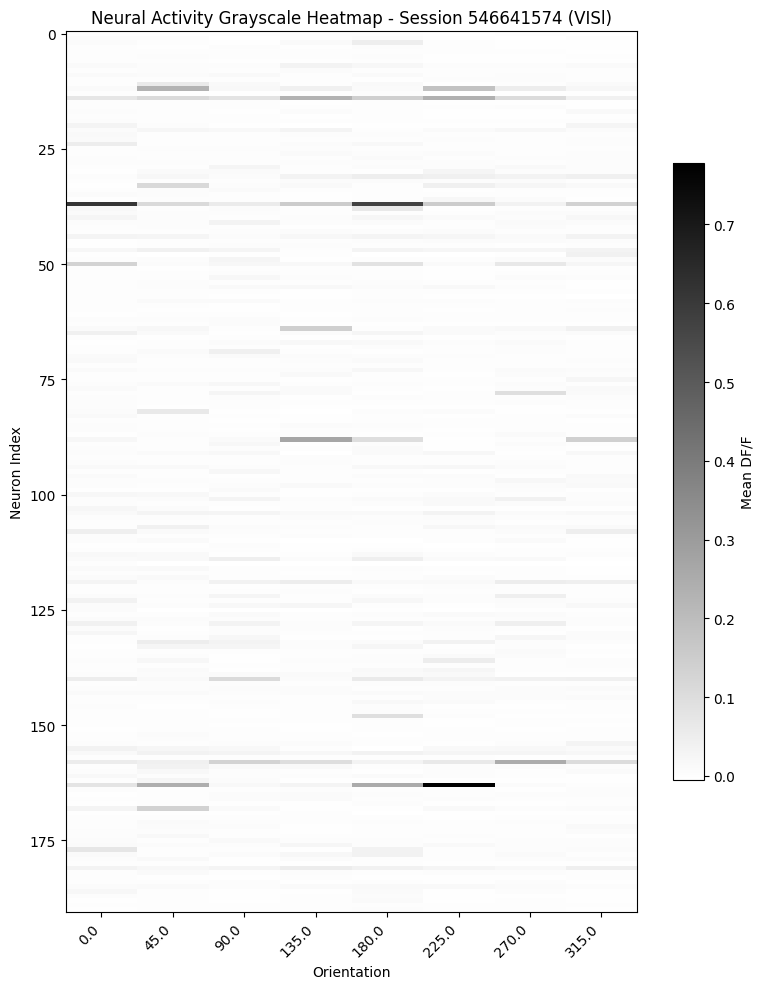

In [86]:
session_id_comparison = 546641574

# Access the data for that session
data_set_comparison = boc.get_ophys_experiment_data(session_id_comparison)

# Get dff traces and stimulus table
_, dff_session_comparison = data_set_comparison.get_dff_traces()
stim_table_session_comparison = data_set_comparison.get_stimulus_table('drifting_gratings')

# Compute orientation-only response and stim labels
response_session_comparison, stim_session_labels_comparison = compute_stim_and_response(dff_session_comparison, stim_table_session_comparison)

# Compute orientation tuning curves
tuning_curves_session_comparison = compute_dg_tuning_curve(response_session_comparison, stim_session_labels_comparison, stim_table_session_comparison)

# Get orientation labels for plotting
orientations_comparison = np.sort(stim_table_session_comparison.orientation.unique())
# Exclude 'nan' and ensure they are floats for sorting
orientation_labels_filtered_comparison = [str(ori) for ori in orientations_comparison if not np.isnan(ori)]

fig_comp, ax_comp = plt.subplots(1, 1, figsize=(8, 10))

im_comp = ax_comp.imshow(tuning_curves_session_comparison, cmap='gray_r', aspect='auto', interpolation='nearest')
ax_comp.set_title(f'Neural Activity Grayscale Heatmap - Session {session_id_comparison} (VISl)')
ax_comp.set_xlabel('Orientation')
ax_comp.set_ylabel('Neuron Index')

# Set x-ticks to correspond to orientations
x_tick_labels_comp = [label for label in orientation_labels_filtered_comparison]
ax_comp.set_xticks(np.arange(len(x_tick_labels_comp)))
ax_comp.set_xticklabels(x_tick_labels_comp, rotation=45, ha='right')

fig_comp.colorbar(im_comp, ax=ax_comp, shrink=0.7, label='Mean DF/F')

plt.tight_layout()
plt.show()

### Interpretation of the Heatmap for Session 546641574 (VISl)

This grayscale heatmap visualizes the average neural activity (Mean DF/F) of individual neurons in **Session 546641574** (from the **VISl** region) as a function of the presented orientation. Similar to the previous heatmap:

*   **Y-axis (Neuron Index):** Each row represents a single neuron recorded during this session.
*   **X-axis (Orientation):** Each column corresponds to a specific drifting grating orientation (0°, 45°, 90°, etc.).
*   **Grayscale Intensity (Mean DF/F):** Lighter shades indicate higher mean neural activity (stronger response to that orientation), while darker shades indicate lower mean activity.

### Comparison with Session 510214538 (VISp)

When comparing this VISl session (546641574) to the VISp session (510214538):

1.  **Neuron Count:** Session 546641574 has 191 neurons, which is indeed fewer than the 284 neurons in Session 510214538. This difference in neuron count should be kept in mind when visually comparing the density of the heatmaps, as fewer rows mean a less comprehensive sampling of the neural population.

2.  **Activity Patterns (Visual Inspection):**
    *   **Specificity:** Observe if neurons in VISl show similar levels of 'orientation selectivity' (bright bands for specific orientations) compared to VISp. Do you see a comparable proportion of neurons with strong, narrow tuning, or do they appear more broadly tuned or less responsive overall?
    *   **Overall Brightness/Response Magnitude:** While both heatmaps use the same grayscale intensity scale (Mean DF/F), a visual comparison can hint at whether the overall response magnitude in VISl is similar, higher, or lower than in VISp.
    *   **Distribution of Tuning:** In the VISp heatmap, we saw distinct groups of neurons responding to various orientations. For VISl, look for similar organizational principles or noticeable differences. Are the 'hotspots' of activity concentrated or more distributed across orientations?

By comparing these heatmaps, we can begin to gain insights into how neural representations of visual stimuli might differ across distinct visual brain regions, even when considering populations with similar (though not identical) numbers of active neurons. The next step could involve more quantitative comparisons of tuning curve properties between the two regions.